In [3]:
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import ICA
import pandas as pd
import seaborn as sns
from mne.stats import permutation_cluster_test
from mpl_toolkits.mplot3d import Axes3D
import urllib.request
import scipy.io as sio
import os
from scipy import stats
from collections import defaultdict


In [4]:
# Stier
bdf_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/LuChris_1.bdf"
csv_path = r"C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/data_p9876_20260508_1018.csv"

# Indlæsning af data
raw = mne.io.read_raw_bdf(bdf_path, preload=True)   # .bdf
raw.resample(256)
raw = raw.notch_filter(50)
raw.set_eeg_reference('average', projection=False)
df = pd.read_csv(csv_path)                          # .csv

Extracting BDF parameters from C:/Users/lundb/OneDrive/Skrivebord/KU/4. Semester/EM3/Projekt/LuChris_1.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6557695  =      0.000 ...  3202.000 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 65536 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1292 events found on stim channel Status
Event IDs: [    1     2     3     4 65536]
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windo

In [5]:
# ICA (Independent Component Analysis) For at fjerne øjenblink
raw_ica = raw.copy().filter(l_freq=1.0, h_freq=40.0)
ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter='auto')
ica.fit(raw_ica, decim=3)

# Bed MNE om automatisk at finde blink vha. de forreste elektroder.
eog_channels = ['Fp1', 'Fp2', 'Fpz']
try:
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
    print(f"ICA fandt blink i komponent(er): {eog_indices}")
    ica.exclude = eog_indices
except Exception as e:
    print(f"Kunne ikke finde EOG automatisk (tjek elektrodenavne). Kør ica.plot_components(raw) for at vælge manuelt.")

# Filtrer den RIGTIGE data til ERP-brug (0.1 - 30 Hz) og træk blink-komponenterne ud
raw_clean = raw.copy().filter(l_freq=0.1, h_freq=40.0)
ica.apply(raw_clean)

# Find triggers
events = mne.find_events(raw_clean, stim_channel='Status')

# Sikkerhedstjek: Antal triggers fra EEG skal matche antal trials i CSV
if len(events) > len(df):
    print("Fandt ekstra start/stop triggers i EEG'et. Fjerner dem for at matche CSV...")
    events = events[-len(df):]

tmin, tmax = -0.2, 0.8
reject_criteria = dict(eeg=150e-6)

epochs = mne.Epochs(
    raw_clean,
    events,
    metadata = df,
    #event_id=event_dict,
    tmin=tmin,
    tmax=tmax,
    baseline=(tmin, 0), # Nulstil baseline (-0.2 til 0) så alle starter samme sted
    preload=True,
    reject=reject_criteria
)

# Hvilke epochs der er droppet efter ICA
print(epochs.drop_log_stats())


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 12.4s.
Using EOG channels: Fp1, Fp2, Fpz
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- L

In [ ]:
blocks_to_exclude = [1,2,3,4,5,6,7,11,15,19,23,27] #1,2,3,4,5,6 (Training) ,7,11,15,19,23,27 (Habituation)
epochs_main = epochs[f"block_num not in {blocks_to_exclude}"]
epochs_correct = epochs_main["correct == True"]
print(f"Beholder {len(epochs_correct)} trials til selve ERP analysen.")

Beholder 998 trials til selve ERP analysen.


In [ ]:
num_deviants = len(epochs_correct["stimulus_state == 'deviant'"])
num_standards = len(epochs_correct["stimulus_state == 'standard'"])

print(f"\nUd af {len(epochs_correct)} korrekte trials:")
print(f"- Standard trials: {num_standards}")
print(f"- Deviant trials: {num_deviants}")

print("\nFordeling af deviants per type og blok-betingelse:")
deviant_metadata = epochs_correct.metadata[epochs_correct.metadata['stimulus_state'] == 'deviant']
print(deviant_metadata.groupby(['block_type', 'deviant_type']).size().reset_index(name='antal'))


Ud af 998 korrekte trials:
- Standard trials: 844
- Deviant trials: 154

Fordeling af deviants per type og blok-betingelse:
  block_type deviant_type  antal
0    Dynamic           AS     27
1    Dynamic           AV     23
2    Dynamic           SV     24
3     Static           AS     27
4     Static           AV     33
5     Static           SV     20


Using a threshold of 3.852182
stat_fun(H1): min=2.9199663858483606e-06 max=12.283930108259225
Running initial clustering …
Found 11 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
C:\Users\lundb\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| Permuting : 999/999 [00:02<00:00,  451.65it/s]


Using a threshold of 3.852182
stat_fun(H1): min=4.510373612965336e-05 max=15.379774315243502
Running initial clustering …
Found 7 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  433.06it/s]


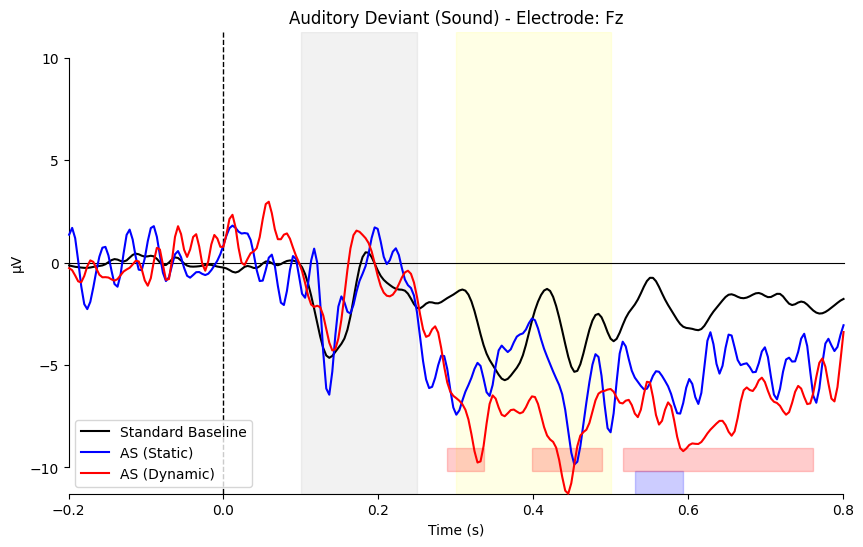

Using a threshold of 3.852182
stat_fun(H1): min=1.0628214629496219e-05 max=8.669002232760576
Running initial clustering …
Found 2 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  458.59it/s]


Using a threshold of 3.852182
stat_fun(H1): min=0.0003033786230974039 max=12.163067813482158
Running initial clustering …
Found 3 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  477.63it/s]


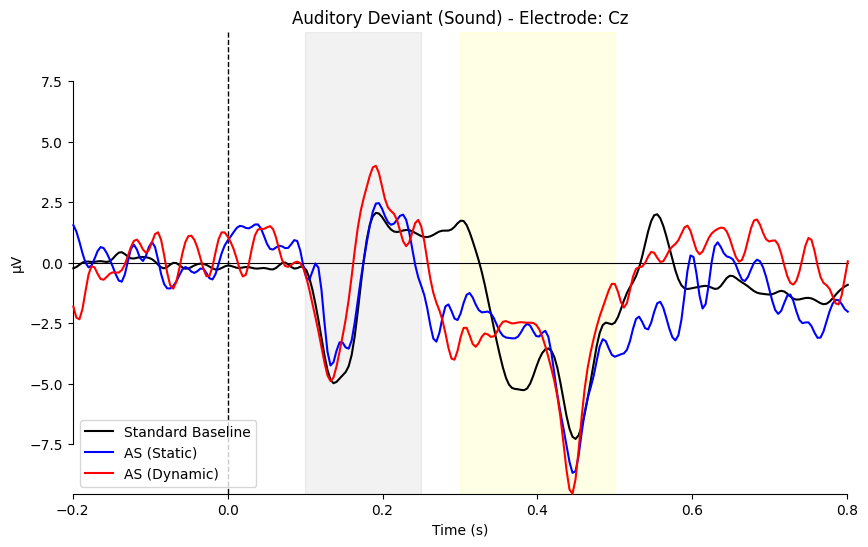

Using a threshold of 3.852269
stat_fun(H1): min=1.662232736091956e-07 max=11.000657236516897
Running initial clustering …
Found 8 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  482.14it/s]


Using a threshold of 3.852219
stat_fun(H1): min=0.0007849433735155587 max=79.98402015539273
Running initial clustering …
Found 9 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  448.91it/s]


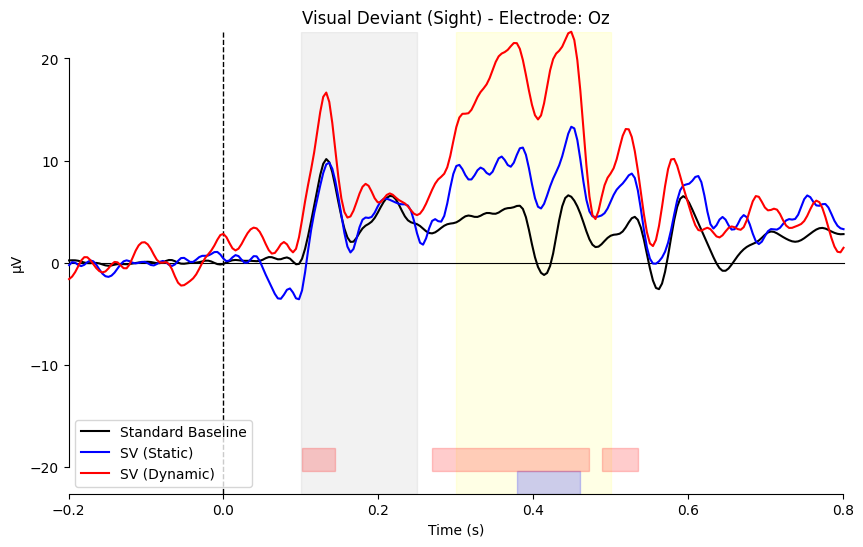

Using a threshold of 3.852269
stat_fun(H1): min=0.0005845211550465244 max=8.36666891449766
Running initial clustering …
Found 9 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  489.10it/s]
C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


Using a threshold of 3.852219
stat_fun(H1): min=0.0009689595667022728 max=48.33382196547457
Running initial clustering …
Found 5 clusters


100%|██████████| Permuting : 999/999 [00:02<00:00,  496.62it/s]


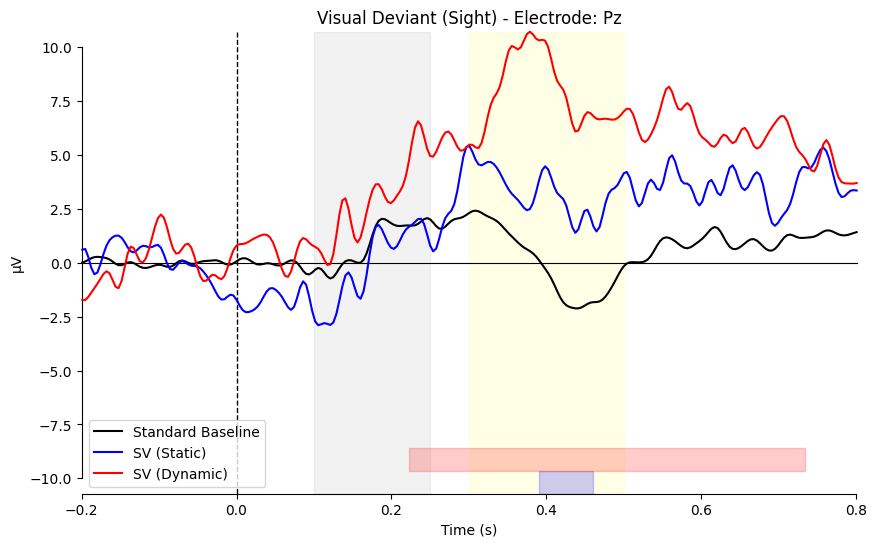

Using a threshold of 3.852108
stat_fun(H1): min=1.4274424710620866e-06 max=9.741888500506752
Running initial clustering …
Found 4 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  471.33it/s]
C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


Using a threshold of 3.852232
stat_fun(H1): min=4.624174861867253e-05 max=8.997289558568474
Running initial clustering …
Found 9 clusters


100%|██████████| Permuting : 999/999 [00:02<00:00,  472.71it/s]


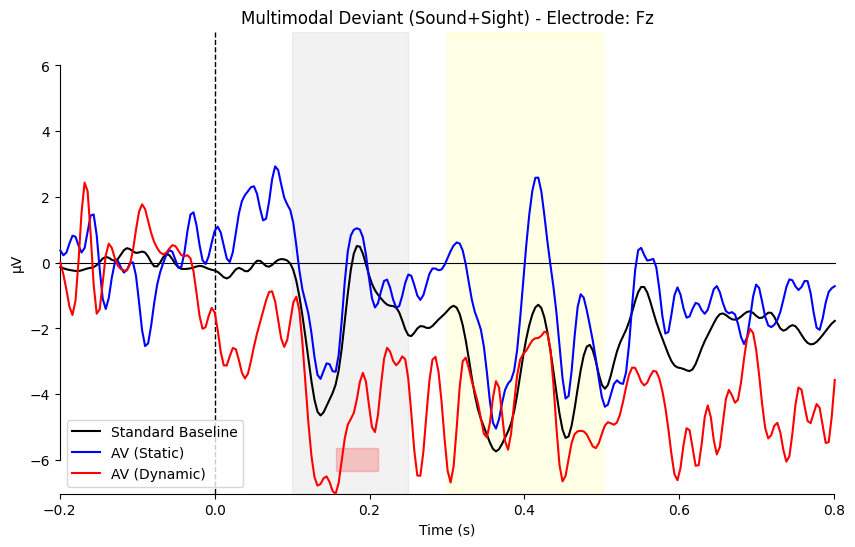

Using a threshold of 3.852108
stat_fun(H1): min=6.825260097315789e-06 max=5.834884949339288
Running initial clustering …
Found 2 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  471.35it/s]


Using a threshold of 3.852232
stat_fun(H1): min=7.19191454743418e-06 max=10.241276788473124
Running initial clustering …
Found 5 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
100%|██████████| Permuting : 999/999 [00:02<00:00,  369.22it/s]


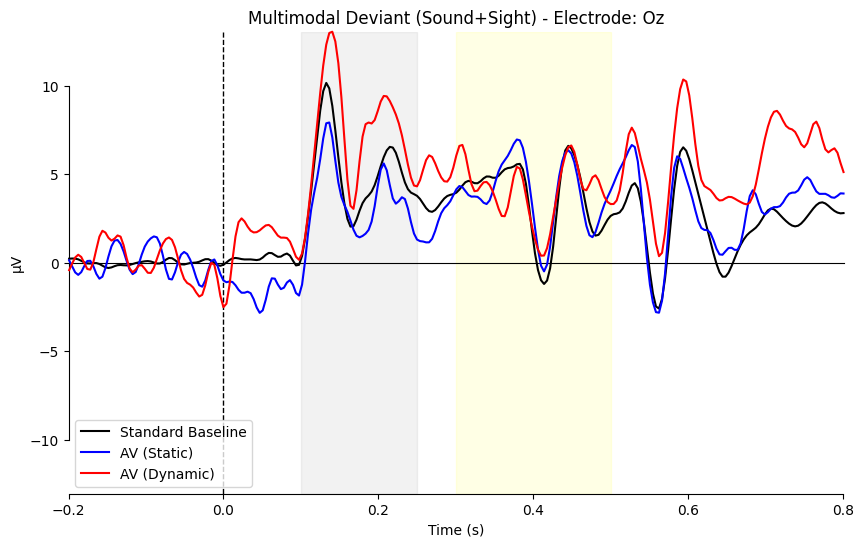

Using a threshold of 3.852108
stat_fun(H1): min=0.00011224634330236202 max=7.5188461168597
Running initial clustering …
Found 3 clusters


C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:72: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
100%|██████████| Permuting : 999/999 [00:02<00:00,  400.28it/s]
C:\Users\lundb\AppData\Local\Temp\ipykernel_14228\2645509154.py:81: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')


Using a threshold of 3.852232
stat_fun(H1): min=3.419748614872319e-05 max=12.613258062210871
Running initial clustering …
Found 4 clusters


100%|██████████| Permuting : 999/999 [00:02<00:00,  425.34it/s]


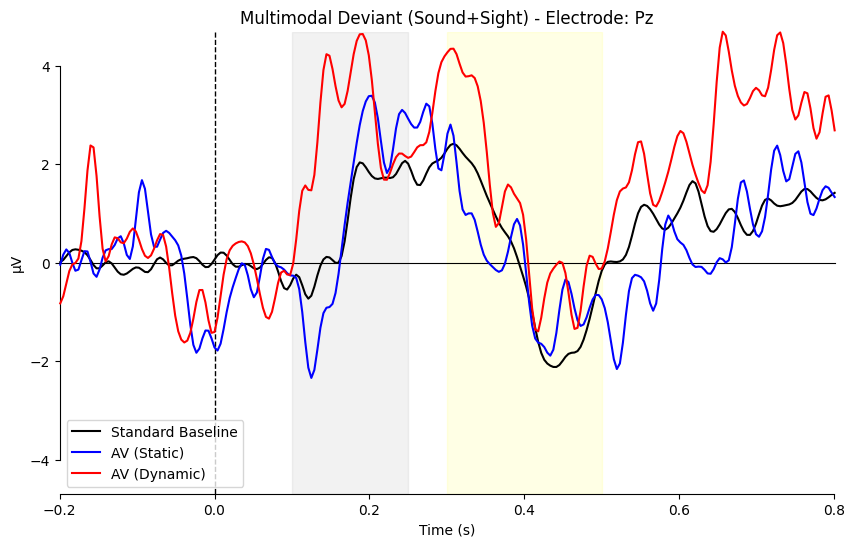

In [9]:
# ==========================================
# 7. ERP PLOTS MED SIGNIFIKANS
# ==========================================

cond_standard = epochs_correct["stimulus_state == 'standard'"].average()

deviant_configs = {
    'AS': {
        'name': 'Auditory Deviant (Sound)',
        'channels': ['Fz', 'Cz']
    },
    'SV': {
        'name': 'Visual Deviant (Sight)',
        'channels': ['Oz', 'Pz']
    },
    'AV': {
        'name': 'Multimodal Deviant (Sound+Sight)',
        'channels': ['Fz', 'Oz', 'Pz']
    }
}

for dev_type, config in deviant_configs.items():

    # Epoch-dataen 
    epochs_static = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"]
    epochs_std = epochs_correct["stimulus_state == 'standard'"]

    # Gennemsnittet
    cond_static = epochs_static.average()
    cond_dynamic = epochs_dyn.average()

    evokeds_dict = {
        'Standard Baseline': cond_standard,
        f'{dev_type} (Static)': cond_static,
        f'{dev_type} (Dynamic)': cond_dynamic
    }

    colors = {
        'Standard Baseline': 'black',
        f'{dev_type} (Static)': 'blue',
        f'{dev_type} (Dynamic)': 'red'
    }

    for ch in config['channels']:
        if ch in epochs_correct.ch_names:

            fig, ax = plt.subplots(figsize=(10, 6))

            mne.viz.plot_compare_evokeds(
                evokeds_dict,
                picks=[ch],
                colors=colors,
                axes=ax,
                title=f"{config['name']} - Electrode: {ch}",
                show_sensors=False,
                show=False 
            )

            ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, zorder=0)
            ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, zorder=0)

            ch_idx = epochs_correct.ch_names.index(ch)
            times = epochs_correct.times

            # Data arrays til klyngetesten
            data_std = epochs_std.get_data(picks=ch_idx).squeeze()
            data_stat = epochs_static.get_data(picks=ch_idx).squeeze()
            data_dyn = epochs_dyn.get_data(picks=ch_idx).squeeze()

            # Test: Er static signifikant forskellig fra Standard?
            _, clusters_stat, p_val_stat, _ = permutation_cluster_test([data_stat, data_std], n_permutations=1000, tail=0, out_type="indices")
            if clusters_stat: # Tjek om den fandt nogle clusters
                for i_c, c in enumerate(clusters_stat):
                    if p_val_stat[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='blue', alpha=0.2, ymin=0.0, ymax=0.05)

            # Test: Er dynamic signifikant forskellig fra Standard?
            _, clusters_dyn, p_val_dyn, _ = permutation_cluster_test([data_dyn, data_std], n_permutations=1000, tail=0, out_type='indices')
            if clusters_dyn: # Tjek om den fandt nogle clusters
                for i_c, c in enumerate(clusters_dyn):
                    if p_val_dyn[i_c] <= 0.05:
                        start_idx = c[0][0]  # Første index i klyngen
                        stop_idx = c[0][-1]  # Sidste index i klyngen
                        ax.axvspan(times[start_idx], times[stop_idx], color='red', alpha=0.2, ymin=0.05, ymax=0.1)

            # Opdater legend og vis grafen
            # For at undgå at signifikans-boksene står 5 gange i boksen, fjerner vi dubletter
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.show()


Beregner antal faktiske afvigere i dataen for alle betingelser...

--- FAKTISK ANTAL DEVIANTS I DATAEN ---
block_type deviant_type  Antal
   Dynamic           AS     27
   Dynamic           AV     23
   Dynamic           SV     24
    Static           AS     27
    Static           AV     33
    Static           SV     20


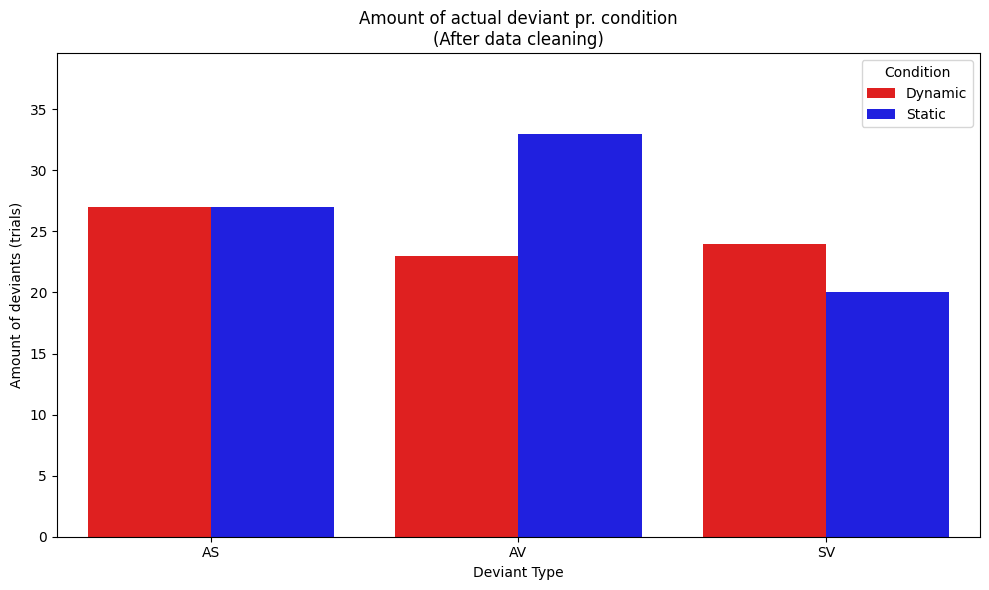

In [11]:
# ==========================================
# 8. TJEK ANTAL DEVIANTS (STATISK VS DYNAMISK)
# ==========================================
print("\nBeregner antal faktiske afvigere i dataen for alle betingelser...")

# Træk den underliggende pandas DataFrame ud fra vores rensede epochs
df_main = epochs_correct.metadata

# Filtrer, så vi KUN kigger på trials, der faktisk var deviants
df_deviants = df_main[df_main['stimulus_state'] == 'deviant']

# Tæl hvor mange der er af hver kombination (block_type x deviant_type)
counts = df_deviants.groupby(['block_type', 'deviant_type']).size().reset_index(name='Antal')

# Print de rå tal i konsollen (Rigtig godt til metodeafsnittet!)
print("\n--- FAKTISK ANTAL DEVIANTS I DATAEN ---")
print(counts.to_string(index=False))

# Lav et flot grupperet bar-plot
plt.figure(figsize=(10, 6))

# Brug 'hue' til at farvekode Statisk/Dynamisk og 'x' til at dele op i AV, SV, AS
sns.barplot(
    data=counts,
    x='deviant_type',
    y='Antal',
    hue='block_type',
    palette={'Static': 'blue', 'Dynamic': 'red'}
)

plt.title('Amount of actual deviant pr. condition\n(After data cleaning)')
plt.ylabel('Amount of deviants (trials)')
plt.xlabel('Deviant Type')

# Sæt y-aksen til at starte ved 0 og give lidt luft i toppen
plt.ylim(0, max(counts['Antal']) * 1.2)

# Gør 'legend' (signaturforklaringen) pænere
plt.legend(title='Condition', loc='upper right')

plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# 9. MARKOV KÆDER: HAZARD RATE PÅ P300
# ==========================================
import copy

# 1. Frasorter fejl-trials først! (Guldstandard)
epochs_correct = epochs_main["correct == True"]

# 2. Hent metadataen for at tilføje vores tæller
m = epochs_correct.metadata.copy()

# 3. Kør igennem alle trials og tæl hvor mange standarder, der har været i træk
run_lengths = []
current_run = 0

for state in m['stimulus_state']:
    if state == 'standard':
        current_run += 1
        run_lengths.append(current_run)
    else: # Hvis det er en deviant
        # Gem hvor mange standarder der kom LIGE FØR denne deviant
        run_lengths.append(current_run)
        current_run = 0 # Nulstil tælleren

# Tilføj den nye kolonne til vores metadata
m['run_length'] = run_lengths
epochs_correct.metadata = m

Replacing existing metadata with 11 columns



Beregner ERP for Hazard Rate (Tidlig vs Sen Afviger)...


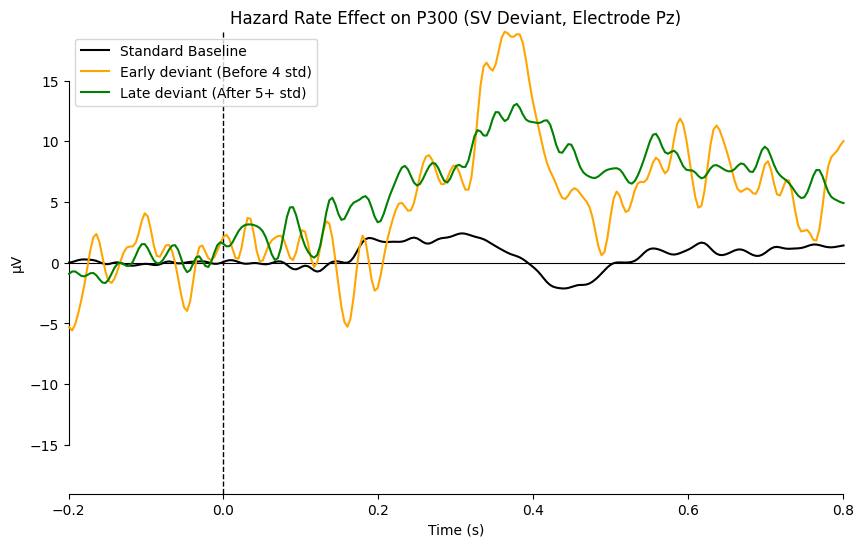

In [16]:
# ==========================================
# PLOT: TIDLIG VS SEN AFVIGER (Kun Dynamiske Blokke)
# ==========================================
print("\nBeregner ERP for Hazard Rate (Tidlig vs Sen Afviger)...")

# Vi kigger kun på 'AV' (Multimodal) i de Dynamiske blokke, da det ofte giver det klareste P300
# Du kan ændre 'AV' til 'SV' eller 'AS'
valgt_afviger = 'SV'

# "Tidlige" afvigere: Kom efter kun 3 eller 4 standarder (Høj surprisal / stor overraskelse)
cond_early = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{valgt_afviger}' and stimulus_state == 'deviant' and run_length < 4"].average()

# "Sene" afvigere: Kom efter 6 eller flere standarder (Lav surprisal / forventet)
cond_late = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{valgt_afviger}' and stimulus_state == 'deviant' and run_length >= 6"].average()

# Den sorte baseline til sammenligning
cond_standard = epochs_correct["stimulus_state == 'standard'"].average()

evokeds_hazard = {
    'Standard Baseline': cond_standard,
    'Early deviant (Before 4 std)': cond_early,
    'Late deviant (After 5+ std)': cond_late
}

colors = {
    'Standard Baseline': 'black',
    'Early deviant (Before 4 std)': 'orange',
    'Late deviant (After 5+ std)': 'green'
}

# Plot Pz for P300
fig, ax = plt.subplots(figsize=(10, 6))

mne.viz.plot_compare_evokeds(
    evokeds_hazard,
    picks=['Pz'],
    colors=colors,
    axes=ax,
    title=f'Hazard Rate Effect on P300 ({valgt_afviger} Deviant, Electrode Pz)',
    show_sensors=False
)

ax.axvspan(0.300, 0.500, color='yellow', alpha=0.2, label='P300 Vindue')
ax.legend(loc='lower left')
plt.show()



Genererer Topografiske kort...


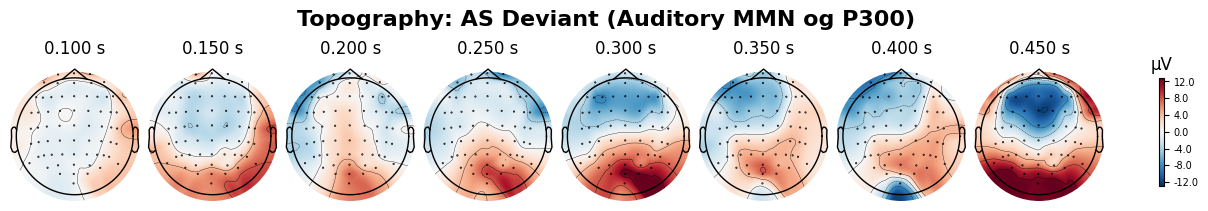

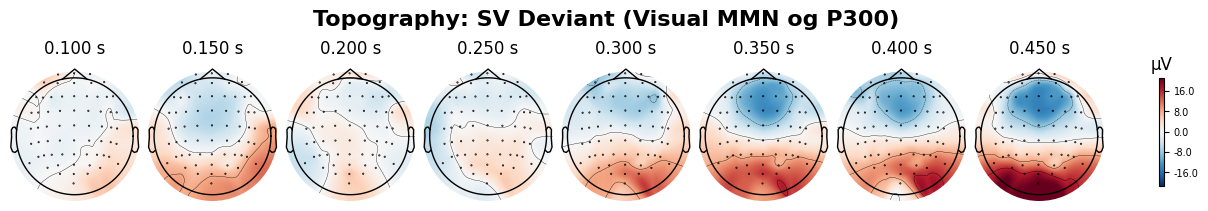

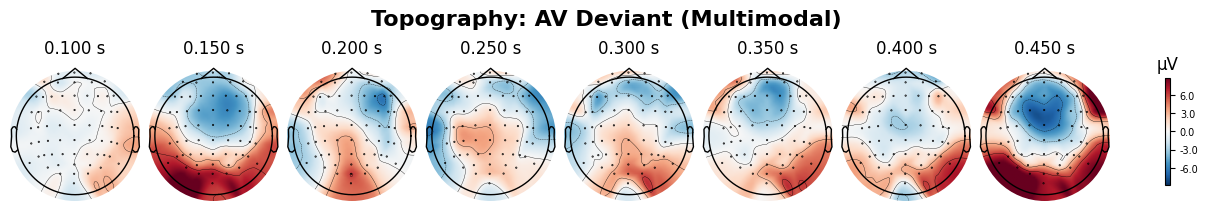

In [17]:
# ==========================================
# 10. TOPOGRAFISKE KORT (TOPOPLOTS)
# ==========================================
print("\nGenererer Topografiske kort...")

try:
    epochs_correct.set_montage('standard_1020')
except ValueError as e:
    print("Bemærk: Kanaler hedder nok noget lokalt (BioSemi), de mangler montage.")

evoked_as = epochs_correct["deviant_type == 'AS' and stimulus_state == 'deviant'"].average()
evoked_sv = epochs_correct["deviant_type == 'SV' and stimulus_state == 'deviant'"].average()
evoked_av = epochs_correct["deviant_type == 'AV' and stimulus_state == 'deviant'"].average()

times_to_plot = [0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400, 0.450]

# --- Plot AS ---
# Vi fanger 'fig' (figuren) som funktionen returnerer
fig_as = evoked_as.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
# Sæt den overordnede titel på selve figuren
fig_as.suptitle("Topography: AS Deviant (Auditory MMN og P300)", fontsize=16, fontweight='bold')

# --- Plot SV ---
fig_sv = evoked_sv.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
fig_sv.suptitle("Topography: SV Deviant (Visual MMN og P300)", fontsize=16, fontweight='bold')

# --- Plot AV ---
fig_av = evoked_av.plot_topomap(times=times_to_plot, ch_type='eeg', time_unit='s', show=False)
fig_av.suptitle("Topography: AV Deviant (Multimodal)", fontsize=16, fontweight='bold')

# Vis dem alle sammen på én gang
plt.show()


Genererer 3D Entropi Landskab for P300...


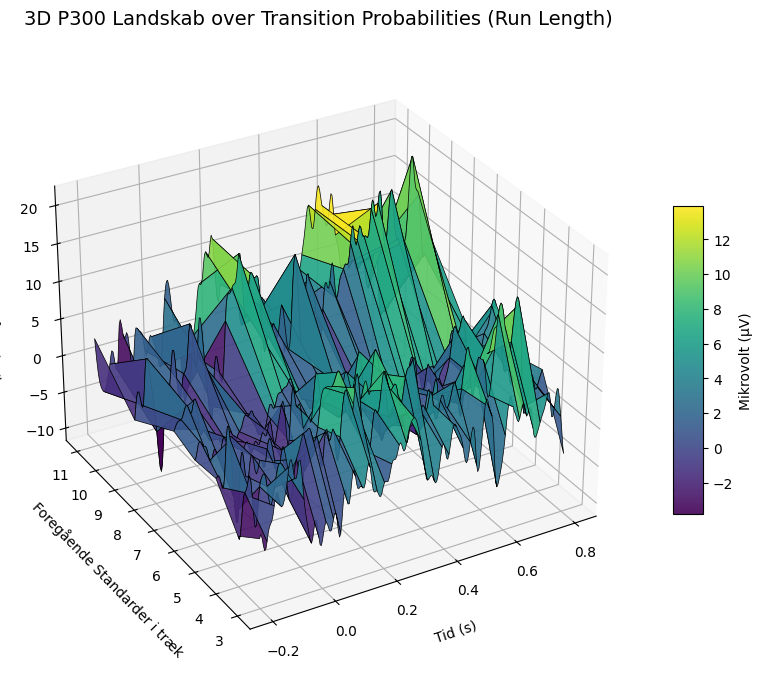

In [18]:
# ==========================================
# 11. 3D ENTOPI / SURPRISAL PLOT (P300)
# ==========================================
print("\nGenererer 3D Entropi Landskab for P300...")

epochs_dyn_av = epochs_correct["block_type == 'Dynamic' and deviant_type == 'AV' and stimulus_state == 'deviant'"]
ch_idx = epochs_correct.ch_names.index('Pz')
times = epochs_correct.times

# Saml de unikke 'run lengths' (vores entropi akse)
unique_runs = np.sort(epochs_dyn_av.metadata['run_length'].unique())

# Vi bygger en Z-matrix der skal holde alle mikrovolt-værdierne
Z_data = []
valid_runs = []

for run_len in unique_runs:
    data_for_run = epochs_dyn_av[f"run_length == {run_len}"].get_data(picks=ch_idx).squeeze()

    # Sikkerhedstjek: Spring over hvis der ikke er noget data
    if data_for_run.size == 0:
        continue

    if data_for_run.ndim == 1:
        mean_erp = data_for_run * 1e6
    else:
        mean_erp = data_for_run.mean(axis=0) * 1e6

    Z_data.append(mean_erp)
    valid_runs.append(run_len)

# Konverter til Numpy arrays
Z = np.array(Z_data)

# Skab et 2D gitter (Meshgrid) for X (Tid) og Y (Run Length)
X, Y = np.meshgrid(times, valid_runs)

# Sæt 3D figuren op
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot LANDSKABET (plot_surface)
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='k', linewidth=0.5, alpha=0.9)

ax.set_title("3D P300 Landskab over Transition Probabilities (Run Length)", pad=20, fontsize=14)
ax.set_xlabel("Tid (s)", labelpad=10)
ax.set_ylabel("Foregående Standarder i træk", labelpad=10)
ax.set_zlabel("Amplitude på Pz (µV)", labelpad=10)

# Tilføj en farveskala (colorbar) til højre for plottet
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Mikrovolt (µV)')

# Roter kameraet lidt for at give den bedste vinkel
ax.view_init(elev=30, azim=-120)

plt.show()


Beregner Difference Waves (Det rene overraskelses-signal)...

Genererer Difference Waves for Auditory Deviant...


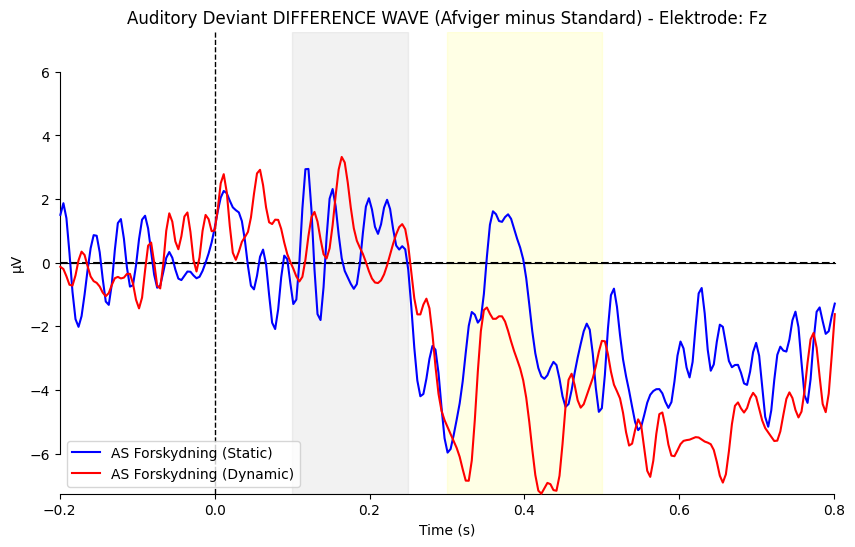

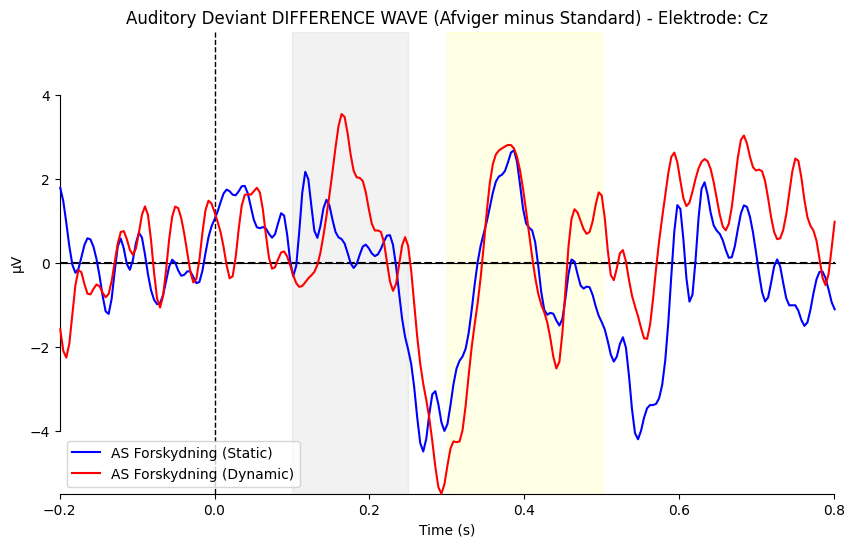


Genererer Difference Waves for Visual Deviant...


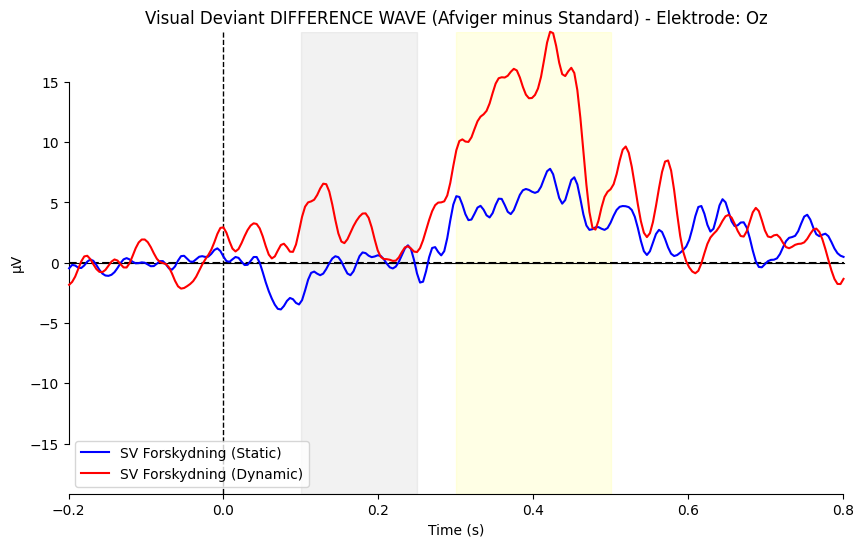

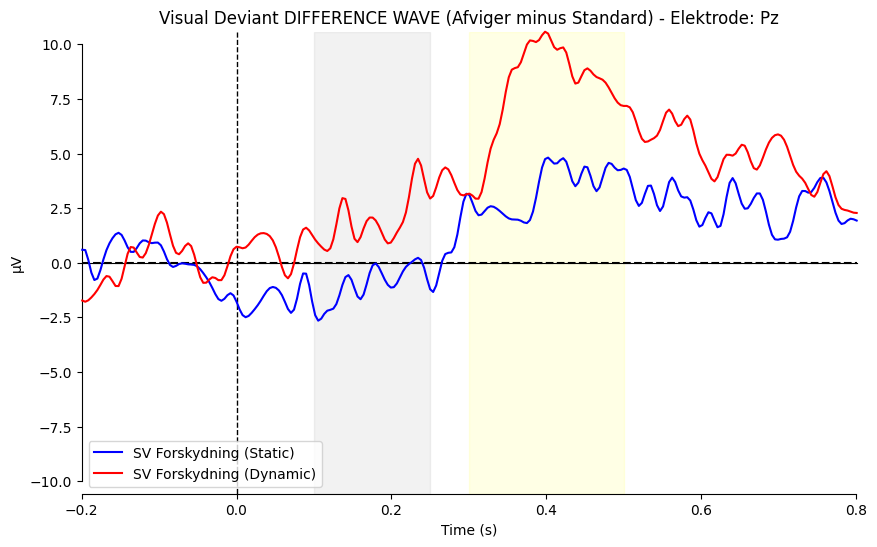


Genererer Difference Waves for Multimodal Deviant...


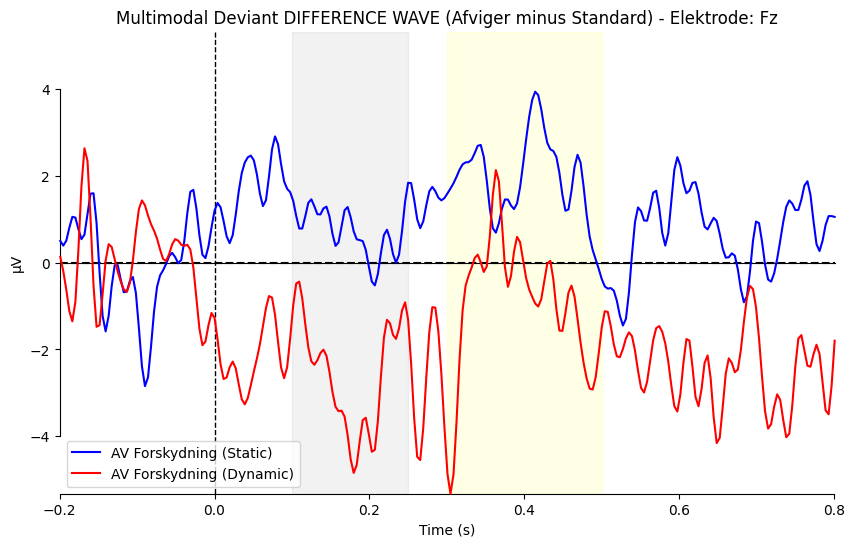

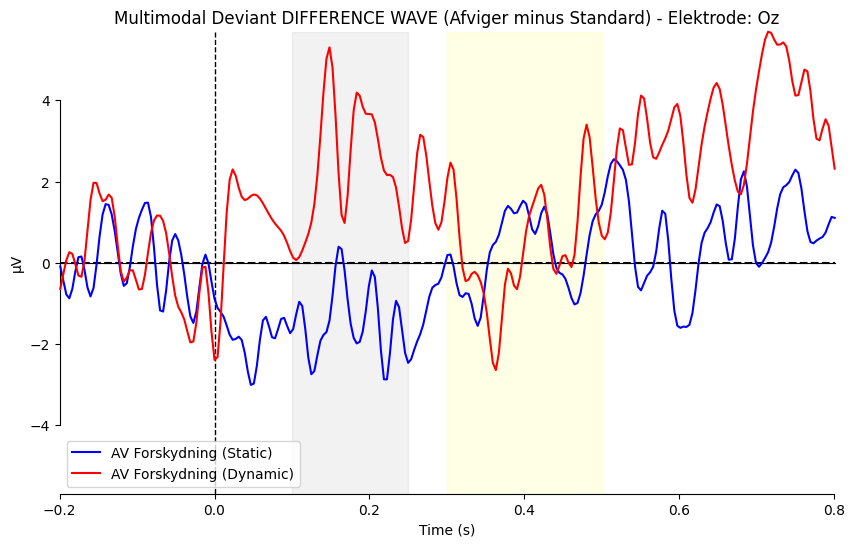

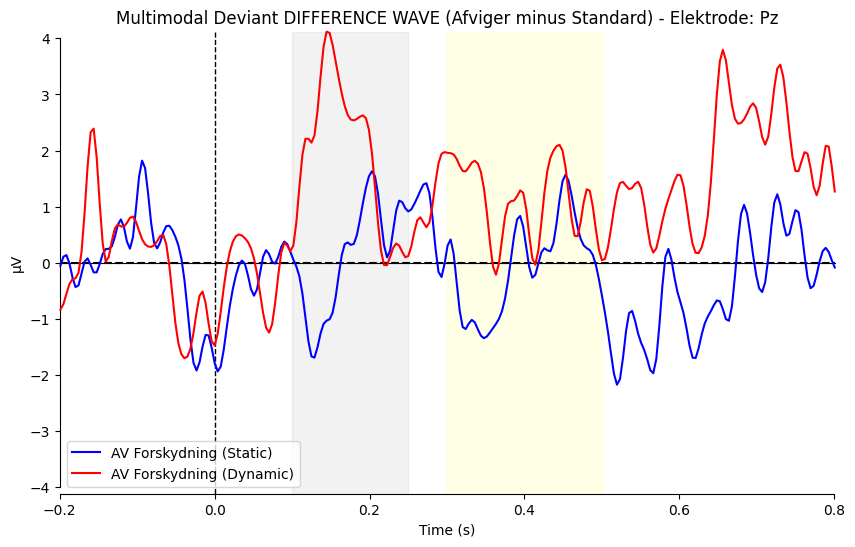

In [19]:
# ==========================================
# 12. DIFFERENCE WAVES (AFVIGER MINUS STANDARD)
# ==========================================
print("\nBeregner Difference Waves (Det rene overraskelses-signal)...")

# Vi skal bruge standarden til at trække fra alle andre
evoked_std = epochs_correct["stimulus_state == 'standard'"].average()

# Vi genbruger din opsætning for elektroderne
deviant_configs = {
    'AS': {'name': 'Auditory Deviant', 'channels': ['Fz', 'Cz']},
    'SV': {'name': 'Visual Deviant', 'channels': ['Oz', 'Pz']},
    'AV': {'name': 'Multimodal Deviant', 'channels': ['Fz', 'Oz', 'Pz']}
}

for dev_type, config in deviant_configs.items():
    print(f"\nGenererer Difference Waves for {config['name']}...")

    # Hent de rene afvigere
    evoked_stat = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()
    evoked_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()

    # BEREGN FORSKELLEN: MNE trækker værdien for standard (vægt -1) fra afvigeren (vægt 1)
    diff_stat = mne.combine_evoked([evoked_stat, evoked_std], weights=[1, -1])
    diff_dyn = mne.combine_evoked([evoked_dyn, evoked_std], weights=[1, -1])

    # Saml dem til plottet
    diff_dict = {
        f'{dev_type} Forskydning (Static)': diff_stat,
        f'{dev_type} Forskydning (Dynamic)': diff_dyn
    }

    colors = {
        f'{dev_type} Forskydning (Static)': 'blue',
        f'{dev_type} Forskydning (Dynamic)': 'red'
    }

    for ch in config['channels']:
        if ch in epochs_correct.ch_names:

            fig, ax = plt.subplots(figsize=(10, 6))

            # Tegn en vandret sort, stiplet linje ved NUL (0 mikrovolt)
            # På en difference wave betyder 0, at hjernen reagerede PRÆCIS ens på standard og afviger!
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)

            mne.viz.plot_compare_evokeds(
                diff_dict,
                picks=[ch],
                colors=colors,
                axes=ax,
                title=f"{config['name']} DIFFERENCE WAVE (Afviger minus Standard) - Elektrode: {ch}",
                show_sensors=False,
                show=False
            )

            # Tegn zonerne i baggrunden
            ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, zorder=0)
            ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, zorder=0)

            # Ryd op i legend (Så den sorte "baseline" linje ikke står der to gange)
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc='lower left')

            plt.show()


Beregner Region of Interest (ROI) for P3a og P3b for ALLE afvigere...

--- Genererer ROI plots for Auditory Deviant (Sound) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


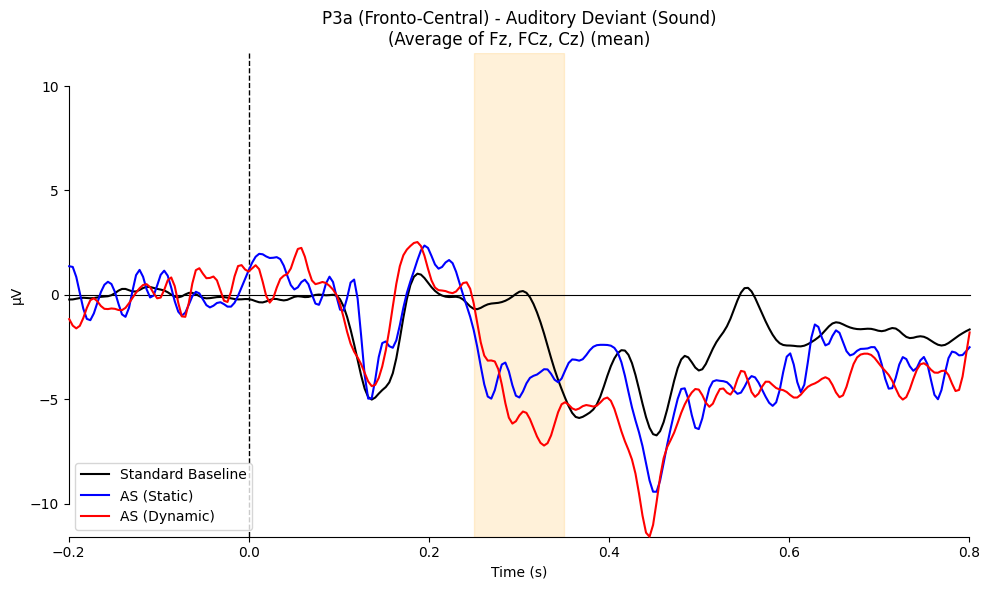

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


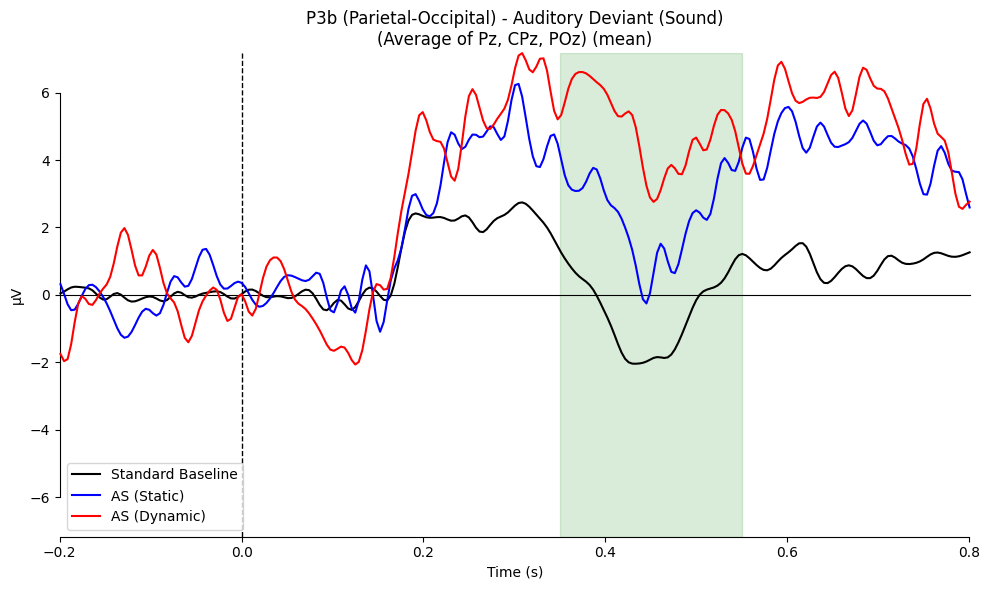


--- Genererer ROI plots for Visual Deviant (Sight) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


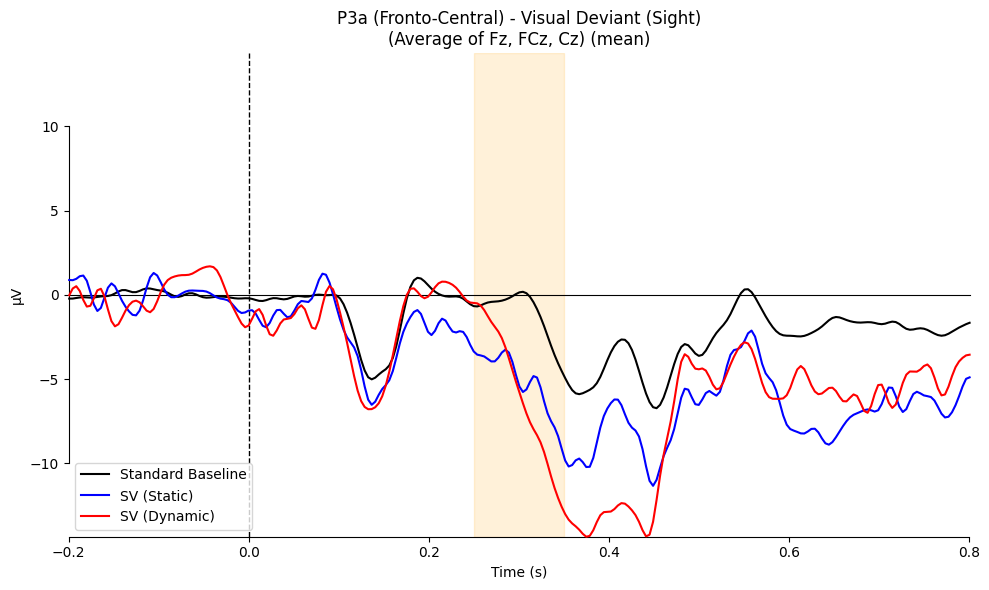

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


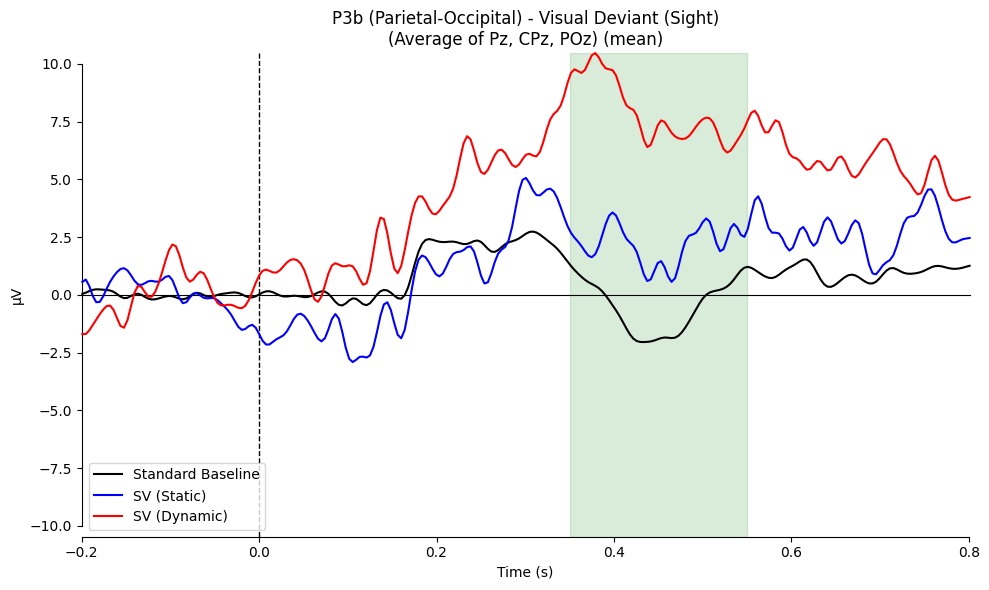


--- Genererer ROI plots for Multimodal Deviant (Sound+Sight) ---
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


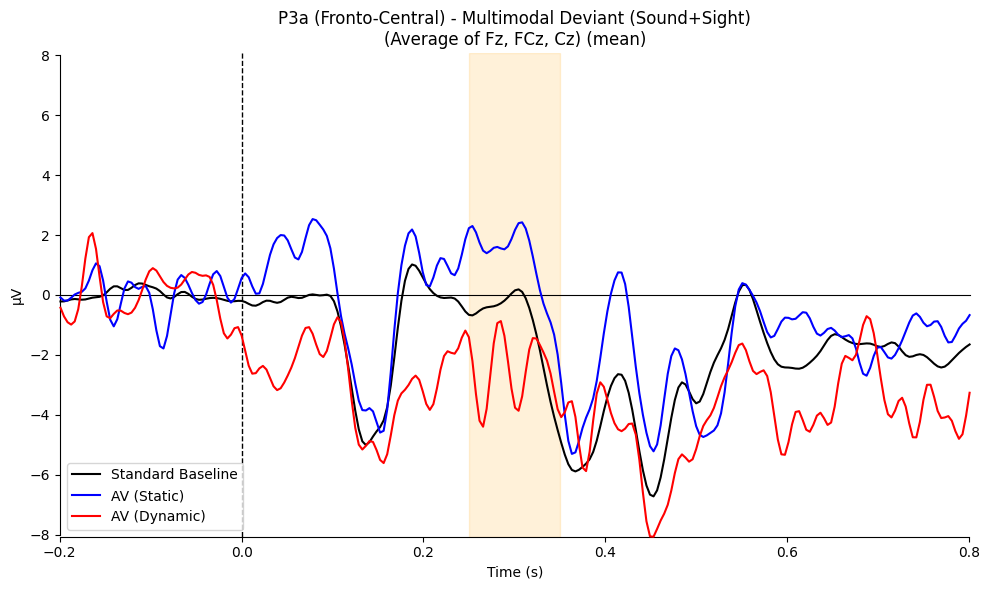

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


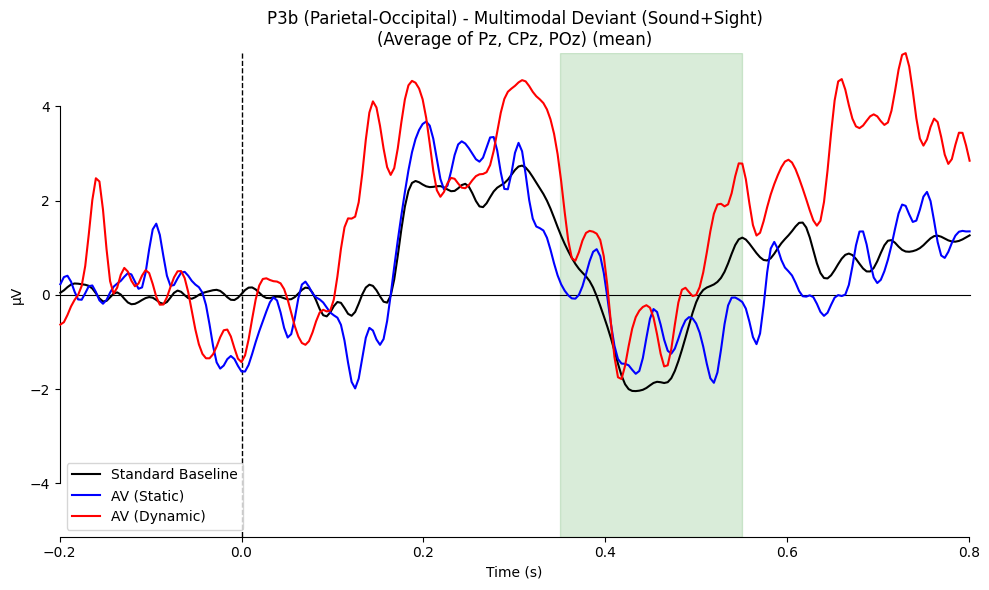

In [20]:
# ==========================================
# 13. P3a vs P3b (Region of Interest Analyse)
# ==========================================
import mne
import matplotlib.pyplot as plt

print("\nBeregner Region of Interest (ROI) for P3a og P3b for ALLE afvigere...")

# 1. Definer vores to Regions of Interest (ROI)
rois = {
    'P3a (Fronto-Central)': ['Fz', 'FCz', 'Cz'],
    'P3b (Parietal-Occipital)': ['Pz', 'CPz', 'POz']
}

# 2. Opsætning af de tre afvigertyper
deviant_names = {
    'AS': 'Auditory Deviant (Sound)',
    'SV': 'Visual Deviant (Sight)',
    'AV': 'Multimodal Deviant (Sound+Sight)'
}

# Hent standard-baselinen (den er ens for alle plots)
evoked_std = epochs_correct["stimulus_state == 'standard'"].average()

# 3. Loop over hver afvigertype (AS, SV, AV)
for dev_type, dev_name in deviant_names.items():
    print(f"\n--- Genererer ROI plots for {dev_name} ---")
    
    # Hent Statisk og Dynamisk for netop denne afviger
    evoked_stat = epochs_correct[f"block_type == 'Static' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()
    evoked_dyn = epochs_correct[f"block_type == 'Dynamic' and deviant_type == '{dev_type}' and stimulus_state == 'deviant'"].average()

    # Saml dem i en ordbog
    evokeds_dict = {
        'Standard Baseline': evoked_std,
        f'{dev_type} (Static)': evoked_stat,
        f'{dev_type} (Dynamic)': evoked_dyn
    }

    colors = {
        'Standard Baseline': 'black', 
        f'{dev_type} (Static)': 'blue', 
        f'{dev_type} (Dynamic)': 'red'
    }

    # 4. Plot for hver ROI for denne afviger
    for roi_name, channels in rois.items():
        # Sikkerhedstjek: Find kun de elektroder, der faktisk findes i jeres data
        valid_channels = [ch for ch in channels if ch in epochs_correct.ch_names]
        
        if not valid_channels:
            print(f"ADVARSEL: Fandt ingen af elektroderne til {roi_name} i dataen!")
            continue
            
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # combine='mean' tager gennemsnittet af kanalerne på tværs af ROI'en
        mne.viz.plot_compare_evokeds(
            evokeds_dict,
            picks=valid_channels,
            combine='mean', 
            colors=colors,
            axes=ax,
            title=f'{roi_name} - {dev_name}\n(Average of {", ".join(valid_channels)})',
            show_sensors=False,
            show=False 
        )
        
        # 5. Marker specifikke tidsvinduer baseret på komponenten
        if 'P3a' in roi_name:
            ax.axvspan(0.250, 0.350, color='orange', alpha=0.15, zorder=0)
        else:
            ax.axvspan(0.350, 0.550, color='green', alpha=0.15, zorder=0)
        
        # Ryd op i signaturforklaringen (legend)
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='lower left')
        
        plt.tight_layout()
        plt.show()

C:\Users\lundb\AppData\Local\Temp\ipykernel_15580\1803139276.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  block_stats = df_main.groupby(['block_num', 'block_type', 'deviant_type']).apply(


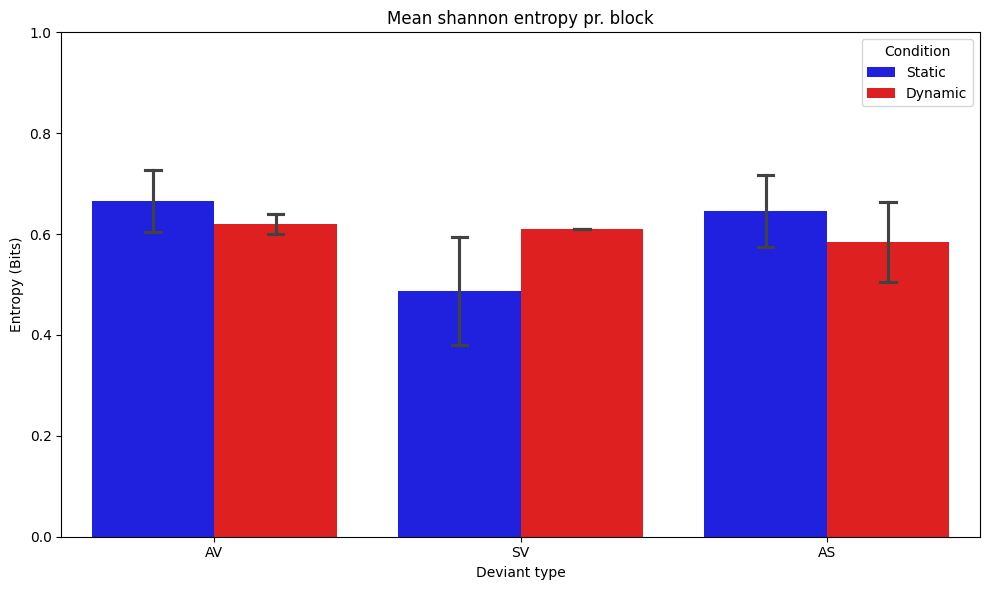

In [21]:
# Gennemsnitlig entropi på tværs af deviants, blokke og konditioner

df_main = df[~df['block_type'].str.contains('Training')].copy()

def shannon_entropy(p):
    if p <= 0 or p >= 1: # Hvis 0% eller 100% sandsynlighed er der 0 entropi (total forudsigelighed)
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# Find den faktiske procentdel af deviants pr. blok
block_stats = df_main.groupby(['block_num', 'block_type', 'deviant_type']).apply(
    lambda x: (x['stimulus_state'] == 'deviant').mean()
).reset_index(name='p_deviant')

# Omregn procentdelen til Shannon Entropi
block_stats['entropy'] = block_stats['p_deviant'].apply(shannon_entropy)

plt.figure(figsize=(10, 6))
# errorbar='sd' tegner standardafvigelsen som en lille sort streg over søjlerne
sns.barplot(
    data=block_stats, 
    x='deviant_type', 
    y='entropy', 
    hue='block_type',
    palette={'Static': 'blue', 'Dynamic': 'red'},
    errorbar='sd',
    capsize=0.1
)

plt.title('Mean shannon entropy pr. block')
plt.ylabel('Entropy (Bits)')
plt.xlabel('Deviant type')
plt.ylim(0, 1) # Entropi for binære valg går fra 0 til 1
plt.legend(title='Condition', loc='upper right')
plt.tight_layout()
plt.show()

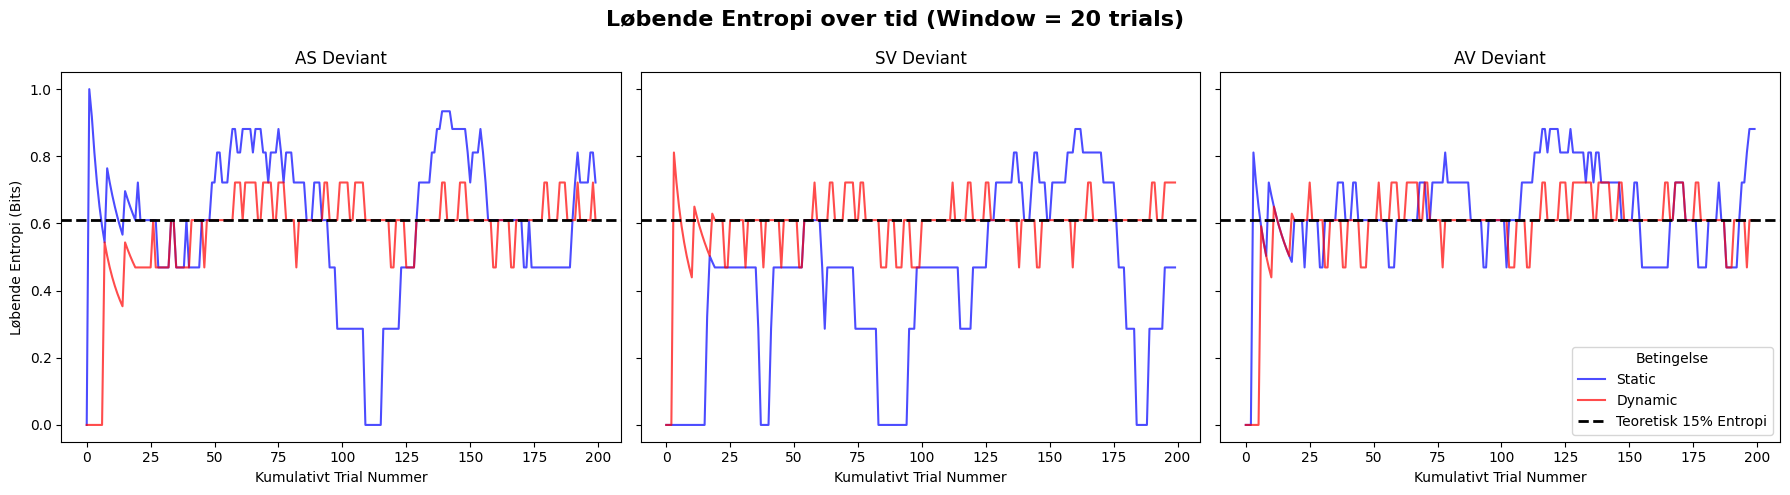

In [22]:
# Løbende entropi

window_size = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(f'Løbende Entropi over tid (Window = {window_size} trials)', fontsize=16, fontweight='bold')

deviant_types = ['AS', 'SV', 'AV']
colors = {'Static': 'blue', 'Dynamic': 'red'}

for i, dev_type in enumerate(deviant_types):
    ax = axes[i]
    
    for b_type in ['Static', 'Dynamic']:
        # Hent data for denne kombination (f.eks. AV Statisk)
        subset = df_main[(df_main['deviant_type'] == dev_type) & (df_main['block_type'] == b_type)].copy()
        
        # Sørg for at de ligger i den rækkefølge, de blev vist i forsøget
        subset = subset.sort_values(['block_num', 'trial_num'])
        
        # Lav en binær kolonne: 1 for deviant, 0 for standard
        subset['is_deviant'] = (subset['stimulus_state'] == 'deviant').astype(int)
        
        # Beregn den løbende sandsynlighed over de sidste 20 trials
        subset['rolling_p'] = subset['is_deviant'].rolling(window=window_size, min_periods=1).mean()
        
        # Beregn den løbende entropi
        subset['rolling_entropy'] = subset['rolling_p'].apply(shannon_entropy)
        
        # Plot resultatet
        ax.plot(range(len(subset)), subset['rolling_entropy'], label=b_type, color=colors[b_type], alpha=0.7, linewidth=1.5)
        
    ax.set_title(f'{dev_type} Deviant')
    ax.set_xlabel('Kumulativt Trial Nummer')
    if i == 0:
        ax.set_ylabel('Løbende Entropi (Bits)')
    ax.set_ylim(-0.05, 1.05)
    
    # En sort streg der viser den "Teoretiske" entropi for 15% (ca. 0.61 bits)
    theoretical_entropy = shannon_entropy(0.15)
    ax.axhline(theoretical_entropy, color='black', linestyle='--', linewidth=2, label='Teoretisk 15% Entropi')
    
    if i == 2:
        ax.legend(title='Betingelse')

plt.tight_layout()
plt.show()

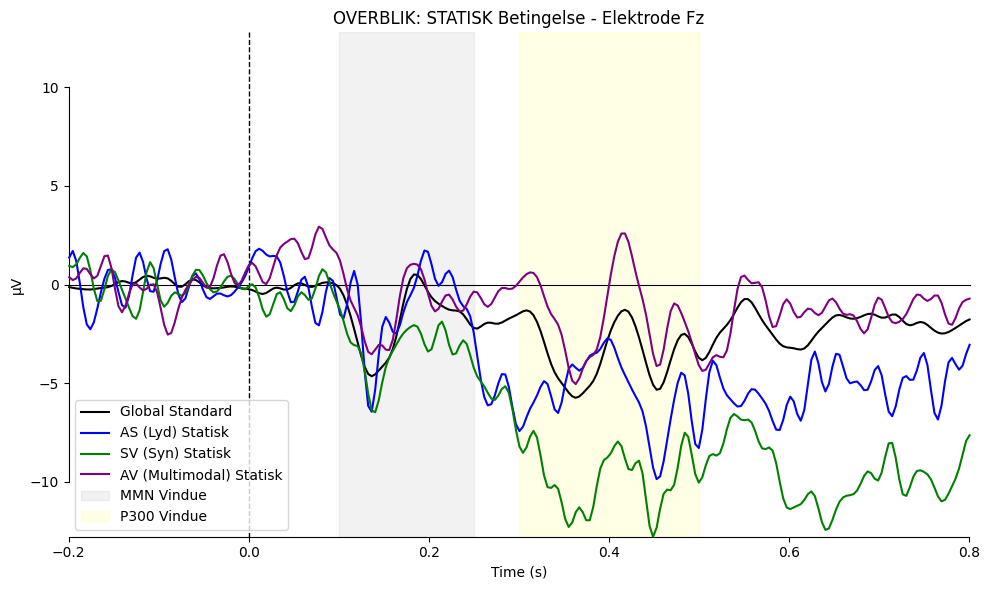

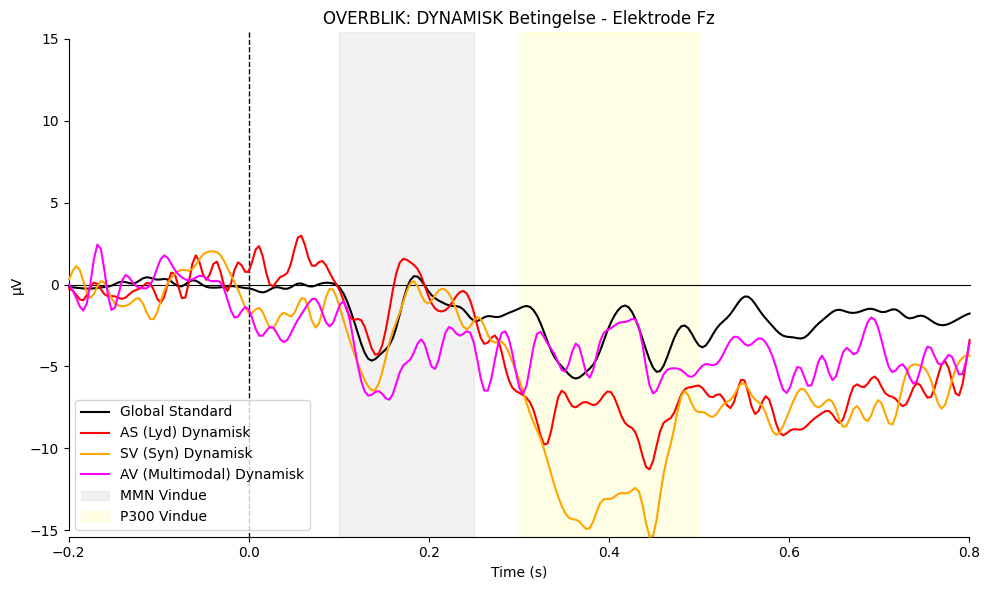

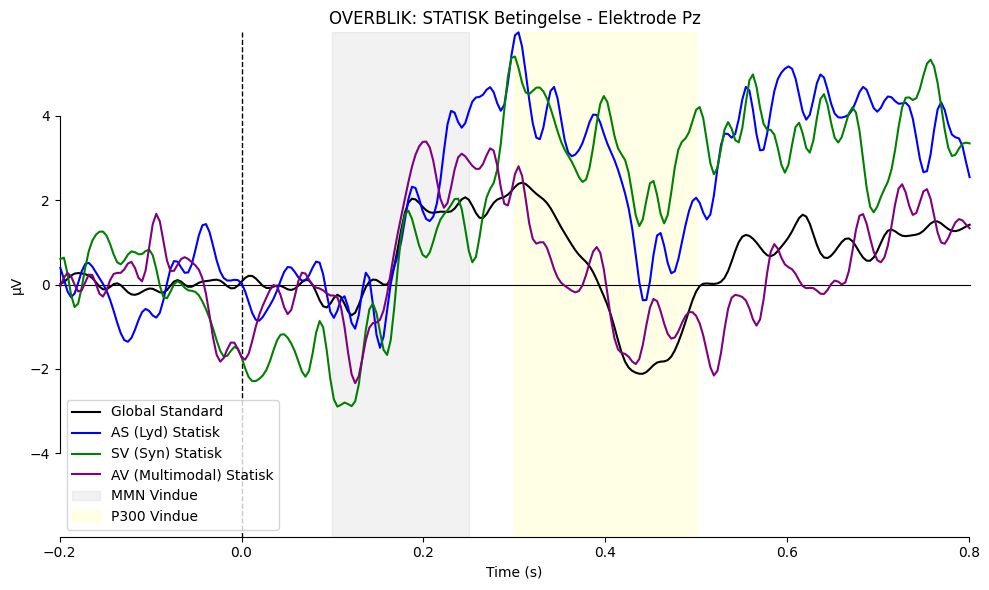

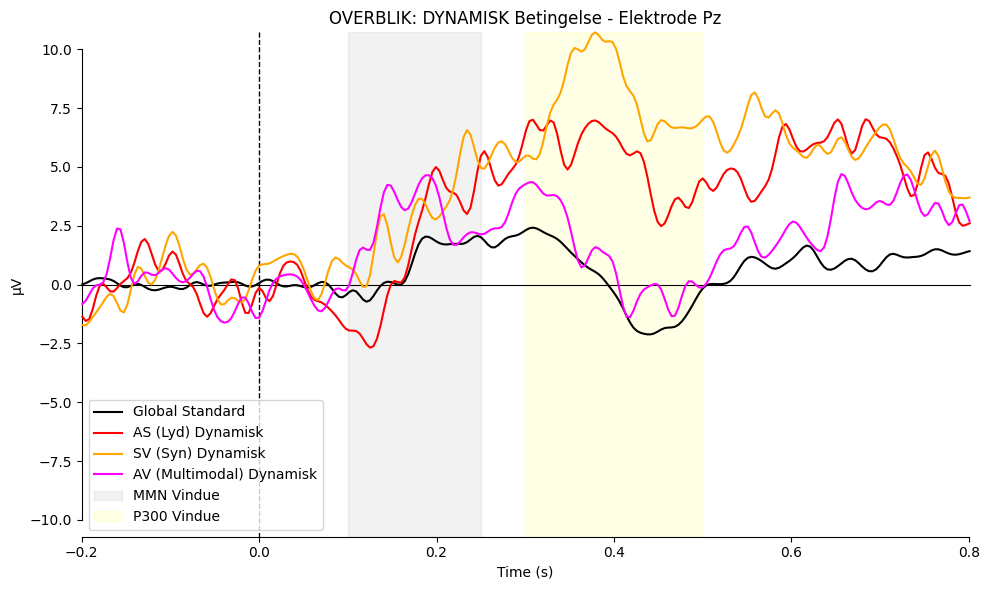

In [23]:
# 1. Skab den Globale Standard (Gennemsnit af ALLE standarder på tværs af alle blokke)
evoked_global_std = epochs_correct["stimulus_state == 'standard'"].average()

# 2. Hent gennemsnittet for alle de individuelle afvigere
evokeds = {
    'AS_stat': epochs_correct["block_type == 'Static' and deviant_type == 'AS' and stimulus_state == 'deviant'"].average(),
    'SV_stat': epochs_correct["block_type == 'Static' and deviant_type == 'SV' and stimulus_state == 'deviant'"].average(),
    'AV_stat': epochs_correct["block_type == 'Static' and deviant_type == 'AV' and stimulus_state == 'deviant'"].average(),
    
    'AS_dyn': epochs_correct["block_type == 'Dynamic' and deviant_type == 'AS' and stimulus_state == 'deviant'"].average(),
    'SV_dyn': epochs_correct["block_type == 'Dynamic' and deviant_type == 'SV' and stimulus_state == 'deviant'"].average(),
    'AV_dyn': epochs_correct["block_type == 'Dynamic' and deviant_type == 'AV' and stimulus_state == 'deviant'"].average()
}

# 3. Opsæt vores to store plots (Statisk og Dynamisk)
plot_configs = {
    'STATISK Betingelse': {
        'dict': {
            'Global Standard': evoked_global_std,
            'AS (Lyd) Statisk': evokeds['AS_stat'],
            'SV (Syn) Statisk': evokeds['SV_stat'],
            'AV (Multimodal) Statisk': evokeds['AV_stat']
        },
        'colors': {'Global Standard': 'black', 'AS (Lyd) Statisk': 'blue', 'SV (Syn) Statisk': 'green', 'AV (Multimodal) Statisk': 'purple'}
    },
    'DYNAMISK Betingelse': {
        'dict': {
            'Global Standard': evoked_global_std,
            'AS (Lyd) Dynamisk': evokeds['AS_dyn'],
            'SV (Syn) Dynamisk': evokeds['SV_dyn'],
            'AV (Multimodal) Dynamisk': evokeds['AV_dyn']
        },
        'colors': {'Global Standard': 'black', 'AS (Lyd) Dynamisk': 'red', 'SV (Syn) Dynamisk': 'orange', 'AV (Multimodal) Dynamisk': 'magenta'}
    }
}

# Vælg hvilke elektroder der er spændende at se dette overblik på
electrodes_to_plot = ['Fz', 'Pz']

for ch in electrodes_to_plot:
    if ch not in epochs_correct.ch_names:
        continue
        
    for condition_name, config in plot_configs.items():
        fig, ax = plt.subplots(figsize=(10, 6))
        
        mne.viz.plot_compare_evokeds(
            config['dict'],
            picks=[ch],
            colors=config['colors'],
            axes=ax,
            title=f"OVERBLIK: {condition_name} - Elektrode {ch}",
            show_sensors=False,
            show=False
        )
        
        # Tegn zoner
        ax.axvspan(0.100, 0.250, color='gray', alpha=0.1, label='MMN Vindue', zorder=0)
        ax.axvspan(0.300, 0.500, color='yellow', alpha=0.1, label='P300 Vindue', zorder=0)
        
        # Ryd op i legend
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='lower left')
        
        plt.tight_layout()
        plt.show()

In [26]:
run_lengths = []

# Vi grupperer dataen per blok (block_num), så vi ikke ved en fejl tæller 
# standarder på tværs af pauserne mellem blokkene.
for block_num, block_data in df.groupby('block_num'):
    
    # Spring eventuelle habituation/trænings-blokke over, hvis du ikke vil have dem med i gennemsnittet
    blocks_to_exclude = [1, 2, 3, 4, 5, 6, 7, 11, 15, 19, 23, 27]
    if block_num in blocks_to_exclude:
        continue

    count = 0 # Tæller til at holde styr på antal standarder
    
    # Løb igennem hver enkelt trial i denne blok
    for index, row in block_data.iterrows():
        
        if row['stimulus_state'] == 'standard':
            count += 1 # Læg 1 til tælleren, når vi ser en standard
            
        elif row['stimulus_state'] == 'deviant':
            # Vi ramte en afviger! Gem hvor mange standarder vi nåede at tælle
            run_lengths.append({
                'block_num': block_num,
                'block_type': row['block_type'],
                'deviant_type': row['deviant_type'],
                'run_length': count
            })
            # Nulstil tælleren, så den er klar til at tælle op til NÆSTE afviger
            count = 0 

# Konverter vores indsamlede data til en Pandas DataFrame
df_runs = pd.DataFrame(run_lengths)

# ==========================================
# BEREGN GENNEMSNIT OG SPREDNING
# ==========================================
# Vi grupperer efter Dynamisk/Statisk og Afviger-type (AS, SV, AV)
# 'mean' = gennemsnit, 'std' = standardafvigelse (spredning), 'count' = antal afvigere
summary = df_runs.groupby(['block_type', 'deviant_type'])['run_length'].agg(['mean', 'std', 'count']).reset_index()

# Gør tabellen pæn og nem at læse
summary.columns = ['Betingelse', 'Afviger Type', 'Gns. Længde (Mean)', 'Spredning (Std)', 'Antal Afvigere']

# Afrund tallene til 2 decimaler
summary['Gns. Længde (Mean)'] = summary['Gns. Længde (Mean)'].round(2)
summary['Spredning (Std)'] = summary['Spredning (Std)'].round(2)

print("STATISTIK FOR SEKVENSLÆNGDER (Antal standarder før en afviger):")
print("-" * 75)
print(summary.to_string(index=False))
print("-" * 75)

STATISTIK FOR SEKVENSLÆNGDER (Antal standarder før en afviger):
---------------------------------------------------------------------------
Betingelse Afviger Type  Gns. Længde (Mean)  Spredning (Std)  Antal Afvigere
   Dynamic           AS                5.25             1.27              28
   Dynamic           AV                5.29             1.41              28
   Dynamic           SV                5.41             1.15              27
    Static           AS                4.71             5.40              31
    Static           AV                4.30             3.42              33
    Static           SV                6.85             7.32              20
---------------------------------------------------------------------------


Filen findes allerede lokalt.
['AAAAA', 'AAABA', 'AABAA', 'AABBA', 'ABAAA', 'ABABA', 'ABBAA', 'ABBBA', 'BAAAA', 'BAABA', 'BABAA', 'BABBA', 'BBAAA', 'BBABA', 'BBBAA', 'BBBBA', 'AAAA', 'AABA', 'ABAA', 'ABBA', 'BAAA', 'BABA', 'BBAA', 'BBBA', 'AAA', 'ABA', 'BAA', 'BBA', 'AA', 'BA', 'A']
Bruger data fra betingelsen hvor P(A) = 0.3
I dette miljø er 'B' Standard (70%) og 'A' er Afviger (30%).


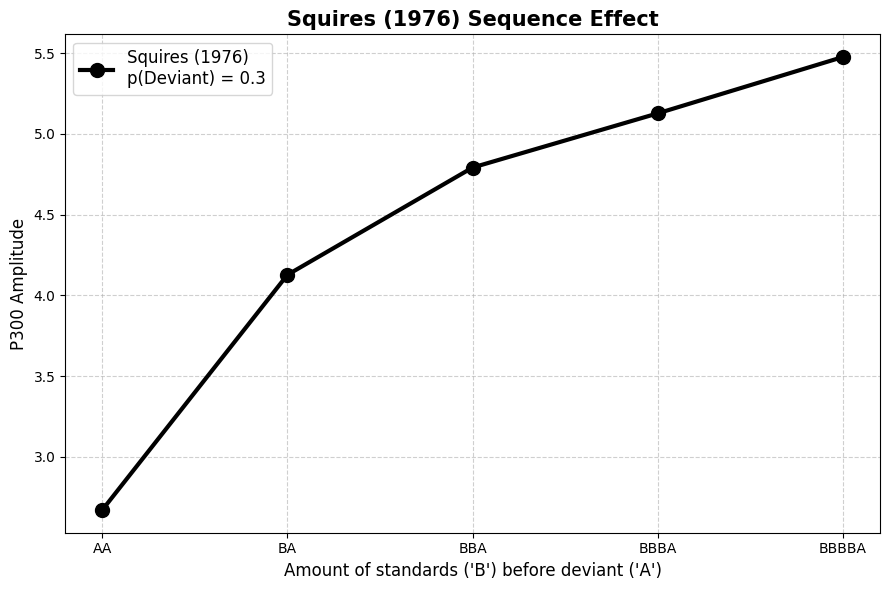

In [27]:
url = "https://raw.githubusercontent.com/florentmeyniel/MinimalTransitionProbsModel/master/Squires1976/Tools/DataSquiresScience1976.mat"
filename = "DataSquiresScience1976.mat"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print("Download fuldført!")
else:
    print("Filen findes allerede lokalt.")

# Indlæs .mat filen (MATLAB format)
squires_data = sio.loadmat(filename)

labels = [str(l[0]) for l in squires_data['label'][0]]
print(labels)
values = squires_data['values']
pA = squires_data['pA'][0]

pA_index = 1
print(f"Bruger data fra betingelsen hvor P(A) = {pA[pA_index]}")
print("I dette miljø er 'B' Standard (70%) og 'A' er Afviger (30%).")

# 4. Definer vores sekvenser (0, 1, 2, 3 og 4 standarder før en afviger)
target_sequences = ['AA', 'BA', 'BBA', 'BBBA', 'BBBBA']
run_lengths = [0, 1, 2, 3, 4]

# 5. Træk P300 værdierne ud for disse specifikke sekvenser
p300_amplitudes = []
for seq in target_sequences:
    if seq in labels:
        idx = labels.index(seq)
        amplitude = values[idx, pA_index]
        p300_amplitudes.append(amplitude)
    else:
        print(f"Sekvens {seq} ikke fundet!")
        p300_amplitudes.append(np.nan)

# ==========================================
# PLOT: SQUIRES (STATISK) P300
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(run_lengths, p300_amplitudes, marker='o', markersize=10, linestyle='-', linewidth=3, color='black', label=f'Squires (1976)\np(Deviant) = 0.3')

ax.set_title("Squires (1976) Sequence Effect", fontsize=15, fontweight='bold')
ax.set_xlabel("Amount of standards ('B') before deviant ('A')", fontsize=12)
ax.set_ylabel("P300 Amplitude", fontsize=12)
ax.set_xticks(run_lengths)
ax.set_xticklabels(target_sequences)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

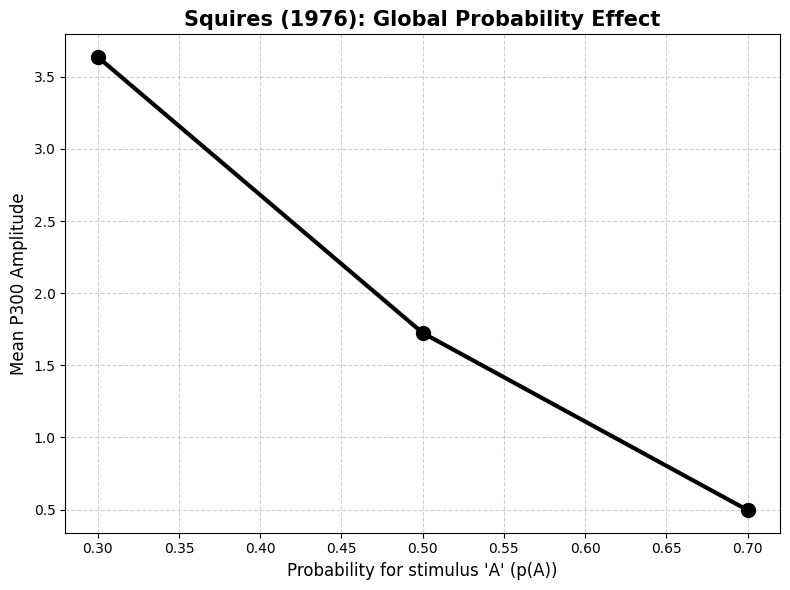

In [28]:
squires_data = sio.loadmat('DataSquiresScience1976.mat')
labels = [str(l[0]) for l in squires_data['label'][0]]
values = squires_data['values']
pA = squires_data['pA'][0] # Giver [0.5, 0.3, 0.7]

# Vi sorterer sandsynlighederne fra lavest til højest for et pænere plot
sort_idx = np.argsort(pA)
pA_sorted = pA[sort_idx] # [0.3, 0.5, 0.7]

# Vi kigger på sekvensen 'A' (Gennemsnittet for alle 'A'-stimuli)
seq = 'A'
if seq in labels:
    idx = labels.index(seq)
    # Hent P300 og sorter dem, så de passer til [0.3, 0.5, 0.7]
    p300_sorted = values[idx, sort_idx] 
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(pA_sorted, p300_sorted, marker='o', markersize=10, linestyle='-', linewidth=3, color='black')
    
    ax.set_title("Squires (1976): Global Probability Effect", fontsize=15, fontweight='bold')
    ax.set_xlabel("Probability for stimulus 'A' (p(A))", fontsize=12)
    ax.set_ylabel("Mean P300 Amplitude", fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

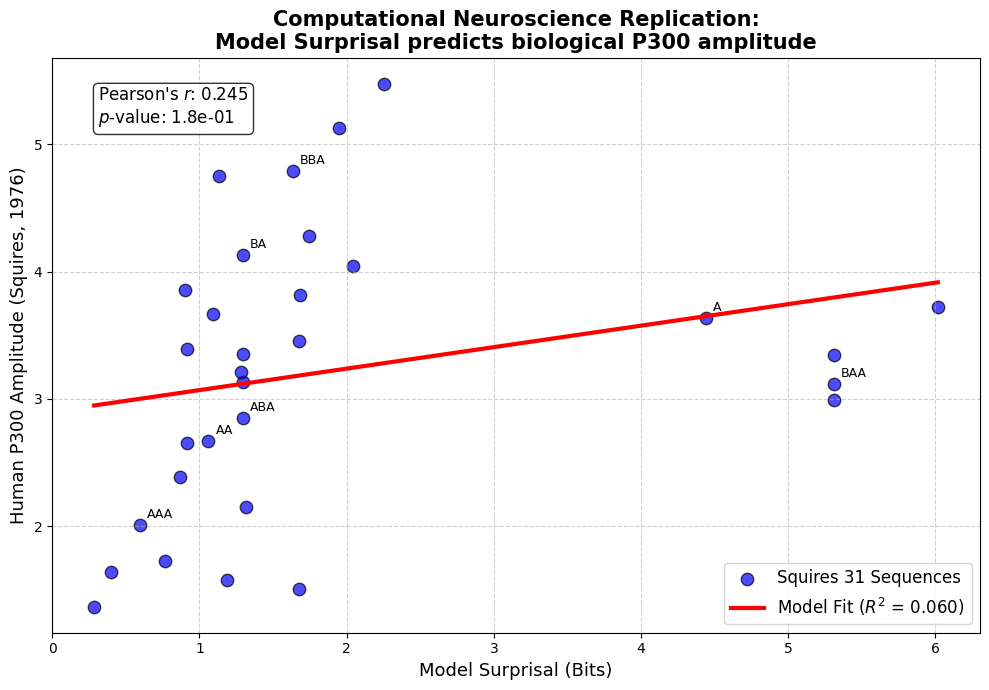

In [ ]:
class LeakyTransitionModel:
    def __init__(self, decay=0.85):
        self.decay = decay
        # Starter med en "flat prior" (add-1 smoothing)
        self.counts = {'A': {'A': 1.0, 'B': 1.0}, 'B': {'A': 1.0, 'B': 1.0}}
        self.prev_item = None

    def update(self, item):
        if self.prev_item is not None:
            # Hukommelsen "henfalder" (leaky memory)
            for p in ['A', 'B']:
                for c in ['A', 'B']:
                    self.counts[p][c] *= self.decay
            
            # Tilføj den nye observation
            self.counts[self.prev_item][item] += 1.0
            
        self.prev_item = item

    def predict_surprisal(self, item):
        if self.prev_item is None:
            return 1.0 # Maksimal overraskelse hvis vi intet ved
        
        # Beregn sandsynlighed P(item | prev_item)
        total_transitions = self.counts[self.prev_item]['A'] + self.counts[self.prev_item]['B']
        prob = self.counts[self.prev_item][item] / total_transitions
        
        # Returner Shannon Surprisal i bits
        return -np.log2(prob)

# ==========================================
# 2. TRÆN MODELLEN OG HENT SQUIRES DATA
# ==========================================

# Indlæs Squires Data
squires_data = sio.loadmat('DataSquiresScience1976.mat')
labels = [str(l[0]) for l in squires_data['label'][0]]
values = squires_data['values']

# Vi bruger p(A) = 0.3 betingelsen (Index 1). Her er B standard (70%) og A afviger (30%)
pA_index = 1 

# For-træn modellen (Burn-in) så den "vænner sig til" miljøet, ligesom en forsøgsperson
np.random.seed(42)
burn_in_sequence = np.random.choice(['A', 'B'], size=20000, p=[0.3, 0.7])

# ==========================================
# 3. KØR ALLE 31 SEKVENSER GENNEM MODELLEN
# ==========================================
model_surprisals = []
human_p300s = []
valid_labels = []

for seq in labels:
    idx = labels.index(seq)
    human_p300 = values[idx, pA_index]
    
    # Spring over hvis der mangler data
    if np.isnan(human_p300):
        continue
        
    # Genstart modellen for hver sekvens, og kør burn-in for at få "standard-hjernen"
    model = LeakyTransitionModel(decay=0.85)
    for item in burn_in_sequence:
        model.update(item)
        
    # Fodr nu den specifikke Squires-sekvens (f.eks. 'BBA') til modellen
    for i in range(len(seq) - 1):
        model.update(seq[i]) # Opdater modellen med alt op til det sidste bogstav
        
    # Hvor overrasket er modellen over det ALLERSIDSTE bogstav i sekvensen?
    final_item = seq[-1]
    surprisal = model.predict_surprisal(final_item)
    
    model_surprisals.append(surprisal)
    human_p300s.append(human_p300)
    valid_labels.append(seq)

# ==========================================
# 4. BEREGN STATISTIK & PLOT
# ==========================================
# Beregn lineær regression (Korrelation mellem Model og Menneske)
slope, intercept, r_value, p_value, std_err = stats.linregress(model_surprisals, human_p300s)

fig, ax = plt.subplots(figsize=(10, 7))

# Tegn selve punkterne
ax.scatter(model_surprisals, human_p300s, color='blue', alpha=0.7, s=80, edgecolor='black', label='Squires 31 Sequences')

# Tegn regressionslinjen
line_x = np.array([min(model_surprisals), max(model_surprisals)])
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, color='red', linewidth=3, label=f'Model Fit ($R^2$ = {r_value**2:.3f})')

# Sæt små navne (f.eks. 'BBA') ud for nogle af de vigtigste punkter
for i, txt in enumerate(valid_labels):
    # Vi printer kun navnet, hvis det ender på afvigeren 'A' (for ikke at gøre plottet uoverskueligt)
    if txt.endswith('A') and len(txt) <= 3: 
        ax.annotate(txt, (model_surprisals[i], human_p300s[i]), xytext=(5, 5), textcoords='offset points', fontsize=9)

# Formatering af plottet
ax.set_title("Computational Neuroscience Replication:\nModel Surprisal predicts biological P300 amplitude", fontsize=15, fontweight='bold')
ax.set_xlabel("Model Surprisal (Bits)", fontsize=13)
ax.set_ylabel("Human P300 Amplitude (Squires, 1976)", fontsize=13)

# Tilføj en boks med statistik
stats_text = f"Pearson's $r$: {r_value:.3f}\n$p$-value: {p_value:.1e}"
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()

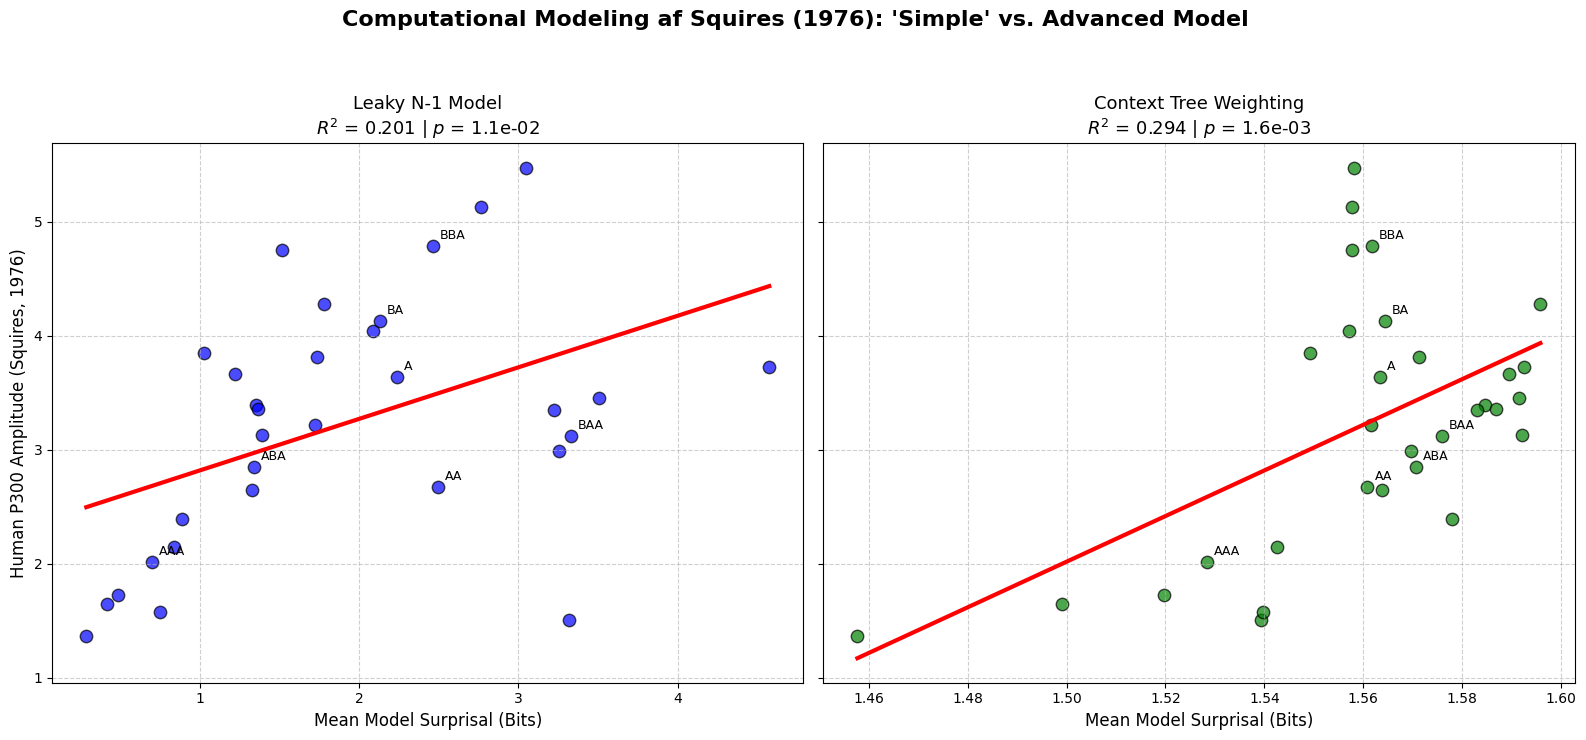

In [18]:
# ==========================================
# 1. DEFINER DE TO MODELLER
# ==========================================
class LeakyTransitionModel:
    def __init__(self, decay=0.85):
        self.decay = decay
        self.counts = {'A': {'A': 1.0, 'B': 1.0}, 'B': {'A': 1.0, 'B': 1.0}}
        self.prev_item = None

    def predict_surprisal(self, item):
        if not self.prev_item: return 1.0
        tot = self.counts[self.prev_item]['A'] + self.counts[self.prev_item]['B']
        return -np.log2(self.counts[self.prev_item][item] / tot)

    def update(self, item):
        if self.prev_item:
            for p in ['A', 'B']:
                for c in ['A', 'B']:
                    self.counts[p][c] *= self.decay
            self.counts[self.prev_item][item] += 1.0
        self.prev_item = item

class ContextTreeModel:
    def __init__(self, max_depth=4):
        self.max_depth = max_depth
        self.tree = {} # Hukommelsestræet

    def predict_surprisal(self, history, item):
        probs = []
        # Kombiner forudsigelser fra kontekster af længde 0 op til max_depth (CTW-princippet)
        for d in range(min(len(history), self.max_depth) + 1):
            ctx = history[len(history)-d:] if d > 0 else ""
            counts = self.tree.get(ctx, {'A': 0.5, 'B': 0.5}) # KT-estimator base
            prob = counts[item] / (counts['A'] + counts['B'])
            probs.append(prob)
        return -np.log2(np.mean(probs))

    def update(self, history, item):
        for d in range(min(len(history), self.max_depth) + 1):
            ctx = history[len(history)-d:] if d > 0 else ""
            if ctx not in self.tree:
                self.tree[ctx] = {'A': 0.5, 'B': 0.5}
            self.tree[ctx][item] += 1.0

# ==========================================
# 2. HENT SQUIRES DATA & Klargør
# ==========================================
squires_data = sio.loadmat('DataSquiresScience1976.mat')
labels = [str(l[0]) for l in squires_data['label'][0]]
values = squires_data['values']
pA_index = 1 # p(A) = 0.3 (A = Afviger, B = Standard)

# ==========================================
# 3. KØR EEG-SIMULERINGEN
# ==========================================
# Vi genererer 20.000 stimuli
np.random.seed(42)
sim_seq = np.random.choice(['A', 'B'], size=20000, p=[0.3, 0.7])

leaky_model = LeakyTransitionModel(decay=0.85)
ctw_model = ContextTreeModel(max_depth=10)

surprisals_leaky = defaultdict(list)
surprisals_ctw = defaultdict(list)

rolling_history = ""

for i in range(len(sim_seq)):
    item = sim_seq[i]
    
    # Beregn Surprisal i DETTE præcise øjeblik
    s_leaky = leaky_model.predict_surprisal(item)
    s_ctw = ctw_model.predict_surprisal(rolling_history, item)
    
    # Tilføj item til historikken, så vi kan se om sekvensen matcher Squires
    rolling_history += item
    if len(rolling_history) > 5:
        rolling_history = rolling_history[-5:] # Squires max længde er 5
        
    # Check om historikken netop nu ender på en af de 31 Squires labels
    for label in labels:
        if rolling_history.endswith(label):
            surprisals_leaky[label].append(s_leaky)
            surprisals_ctw[label].append(s_ctw)
            
    # Opdater modellerne TIL NÆSTE RUNDE
    leaky_model.update(item)
    ctw_model.update(rolling_history[:-1], item) 

# ==========================================
# 4. PLOT SIDE-OM-SIDE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle("Computational Modeling af Squires (1976): 'Simple' vs. Advanced Model", fontsize=16, fontweight='bold', y=1.05)

models_data = [
    ("Leaky N-1 Model", surprisals_leaky, 'blue'),
    ("Context Tree Weighting", surprisals_ctw, 'green')
]

for i, (title, surp_dict, color) in enumerate(models_data):
    ax = axes[i]
    x_vals, y_vals, valid_lbls = [], [], []
    
    for label in labels:
        idx = labels.index(label)
        human_p300 = values[idx, pA_index]
        if np.isnan(human_p300) or len(surp_dict[label]) == 0:
            continue
            
        x_vals.append(np.mean(surp_dict[label])) # Gennemsnitlig surprisal for sekvensen
        y_vals.append(human_p300)
        valid_lbls.append(label)
        
    # Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
    
    # Scatter og Linje
    ax.scatter(x_vals, y_vals, color=color, alpha=0.7, s=80, edgecolor='black')
    line_x = np.array([min(x_vals), max(x_vals)])
    ax.plot(line_x, slope * line_x + intercept, color='red', linewidth=3)
    
    # Annotering af afvigere
    for j, txt in enumerate(valid_lbls):
        if txt.endswith('A') and len(txt) <= 3:
            ax.annotate(txt, (x_vals[j], y_vals[j]), xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax.set_title(f"{title}\n$R^2$ = {r_value**2:.3f} | $p$ = {p_value:.1e}", fontsize=13)
    ax.set_xlabel("Mean Model Surprisal (Bits)", fontsize=12)
    if i == 0: ax.set_ylabel("Human P300 Amplitude (Squires, 1976)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

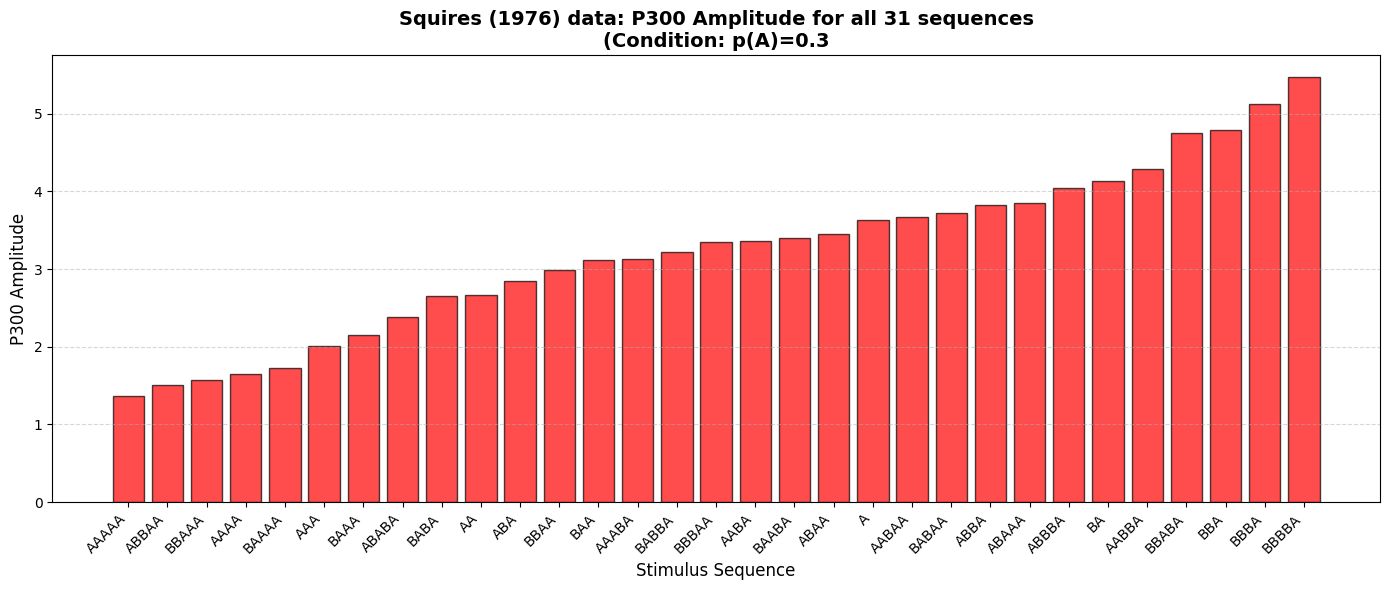

In [20]:
squires_data = sio.loadmat('DataSquiresScience1976.mat')
labels = [str(l[0]) for l in squires_data['label'][0]]
values = squires_data['values']
pA = squires_data['pA'][0]

# Vi vælger p(A) = 0.3 (hvor A er den sjældne afviger, og B is standarden)
pA_index = 1

# Sorter sekvenserne efter deres P300-amplitude, så plottet bliver nemt at læse
sorted_indices = np.argsort(values[:, pA_index])
sorted_labels = [labels[i] for i in sorted_indices if not np.isnan(values[i, pA_index])]
sorted_values = [values[i, pA_index] for i in sorted_indices if not np.isnan(values[i, pA_index])]

# 2. Plot alle 31 sekvenser
plt.figure(figsize=(14, 6))

# Farv sekvenserne alt efter om de ender på en Afviger ('A') eller Standard ('B')
colors = ['red' if lbl.endswith('A') else 'blue' for lbl in sorted_labels]

plt.bar(range(len(sorted_values)), sorted_values, color=colors, alpha=0.7, edgecolor='black')
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=45, ha='right', fontsize=10)

plt.title(f"Squires (1976) data: P300 Amplitude for all 31 sequences\n(Condition: p(A)={pA[pA_index]}", fontsize=14, fontweight='bold')
plt.xlabel("Stimulus Sequence", fontsize=12)
plt.ylabel("P300 Amplitude", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

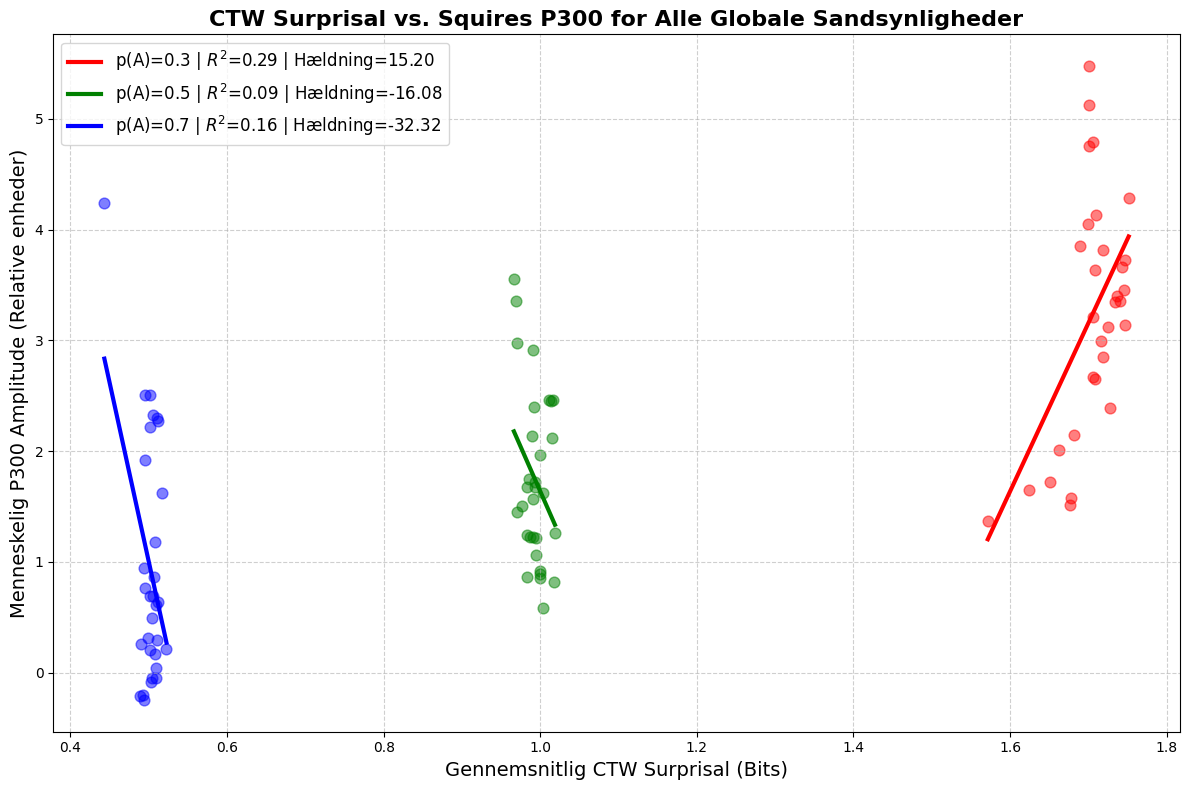

In [30]:
# ==========================================
# 1. CTW MODEL DEFINITION
# ==========================================
class ContextTreeModel:
    def __init__(self, max_depth=4):
        self.max_depth = max_depth
        self.tree = {}

    def predict_surprisal(self, history, item):
        probs = []
        for d in range(min(len(history), self.max_depth) + 1):
            ctx = history[len(history)-d:] if d > 0 else ""
            counts = self.tree.get(ctx, {'A': 0.5, 'B': 0.5})
            prob = counts[item] / (counts['A'] + counts['B'])
            probs.append(prob)
        return -np.log2(np.mean(probs))

    def update(self, history, item):
        for d in range(min(len(history), self.max_depth) + 1):
            ctx = history[len(history)-d:] if d > 0 else ""
            if ctx not in self.tree:
                self.tree[ctx] = {'A': 0.5, 'B': 0.5}
            self.tree[ctx][item] += 1.0

# ==========================================
# 2. INDLÆS DATA OG OPSÆT KØRSEL
# ==========================================
squires_data = sio.loadmat('DataSquiresScience1976.mat')
labels = [str(l[0]) for l in squires_data['label'][0]]
values = squires_data['values']
pAs = list(squires_data['pA'][0]) # [0.5, 0.3, 0.7]

# Vi vil plotte dem med tre forskellige farver
conditions = [
    {'pA': 0.3, 'color': 'red', 'name': 'Sjælden (0.3)'},
    {'pA': 0.5, 'color': 'green', 'name': 'Tilfældig (0.5)'},
    {'pA': 0.7, 'color': 'blue', 'name': 'Hyppig (0.7)'}
]

fig, ax = plt.subplots(figsize=(12, 8))

# ==========================================
# 3. SIMULER OG PLOT FOR HVER SANDSYNLIGHED
# ==========================================
for cond in conditions:
    pA_val = cond['pA']
    idx = pAs.index(pA_val)
    
    # Klargør CTW model og simulerings-sekvens
    ctw_model = ContextTreeModel(max_depth=4)
    np.random.seed(42)
    sim_seq = np.random.choice(['A', 'B'], size=20000, p=[pA_val, 1.0 - pA_val])
    
    surprisals_ctw = defaultdict(list)
    rolling_history = ""

    # Kør 20.000 trials simulation
    for i in range(len(sim_seq)):
        item = sim_seq[i]
        s_ctw = ctw_model.predict_surprisal(rolling_history, item)
        
        rolling_history += item
        if len(rolling_history) > 5:
            rolling_history = rolling_history[-5:]
            
        for label in labels:
            if rolling_history.endswith(label):
                surprisals_ctw[label].append(s_ctw)
                
        ctw_model.update(rolling_history[:-1], item) 

    # Træk data ud til plottet
    x_vals, y_vals = [], []
    for label in labels:
        human_p300 = values[labels.index(label), idx]
        if not np.isnan(human_p300) and len(surprisals_ctw[label]) > 0:
            x_vals.append(np.mean(surprisals_ctw[label]))
            y_vals.append(human_p300)
            
    # Lineær Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
    
    # Scatter og Linje
    ax.scatter(x_vals, y_vals, color=cond['color'], alpha=0.5, s=60)
    line_x = np.array([min(x_vals), max(x_vals)])
    
    label_text = f"p(A)={pA_val} | $R^2$={r_value**2:.2f} | Hældning={slope:.2f}"
    ax.plot(line_x, slope * line_x + intercept, color=cond['color'], linewidth=3, label=label_text)

# ==========================================
# 4. PLOT FORMATERING
# ==========================================
ax.set_title("CTW Surprisal vs. Squires P300 for Alle Globale Sandsynligheder", fontsize=16, fontweight='bold')
ax.set_xlabel("Gennemsnitlig CTW Surprisal (Bits)", fontsize=14)
ax.set_ylabel("Menneskelig P300 Amplitude (Relative enheder)", fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()